In [1]:
#%env JAX_PLATFORM=cpu
%env CUDA_VISIBLE_DEVICES=1
%env XLA_PYTHON_CLIENT_PREALLOCATE=false
%env JAX_ENABLE_X64=True

env: CUDA_VISIBLE_DEVICES=1
env: XLA_PYTHON_CLIENT_PREALLOCATE=false
env: JAX_ENABLE_X64=True


# Setup Simulator

In [2]:
from modules.systems import Cascade, actuator_faults
from env import Simulator
from flax import  nnx
import ppo 

In [3]:
rngs = nnx.Rngs(0)
sys = actuator_faults(Cascade(x_dim=2, u_dim=2, y_dim=1))
env = Simulator(sys, t_aux_on=32, t_aux_off=96, rngs=rngs)
trainer = ppo.Trainer(env, rngs=rngs, discount=0.99, gae_lambda=0.95)
nnx.display(trainer)
logger = trainer.train(epochs=1, episode_length=128)

100%|██████████| 1/1 [00:07<00:00,  7.97s/it, V=-26.4, loss_pi=0.0383, loss_vf=400, reward=-2.09]


# Untrained policy

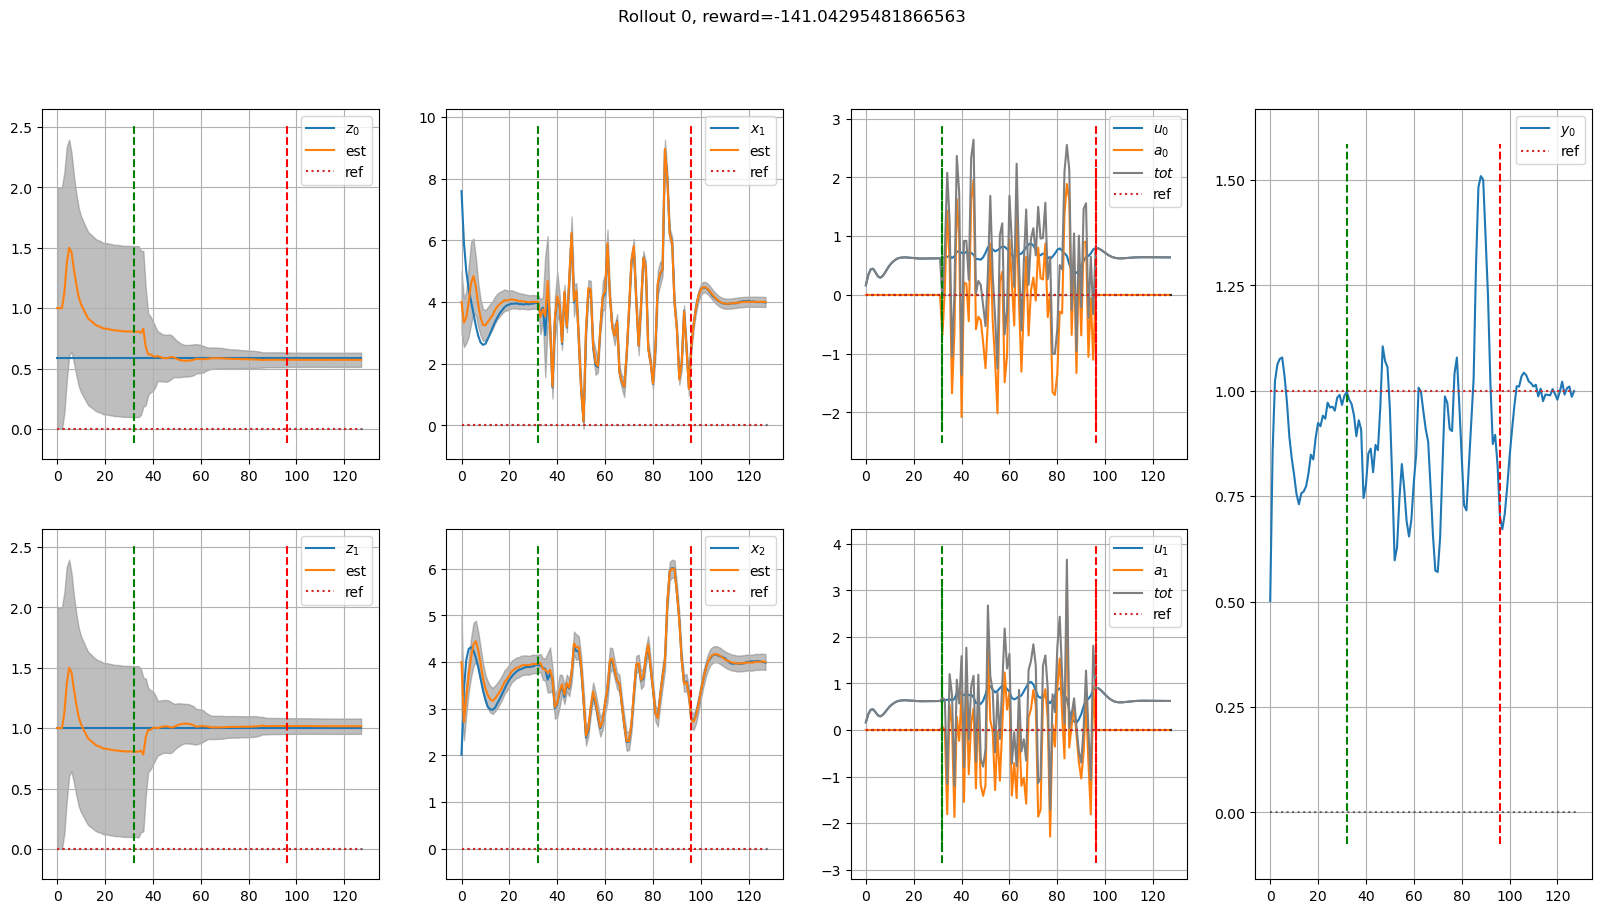

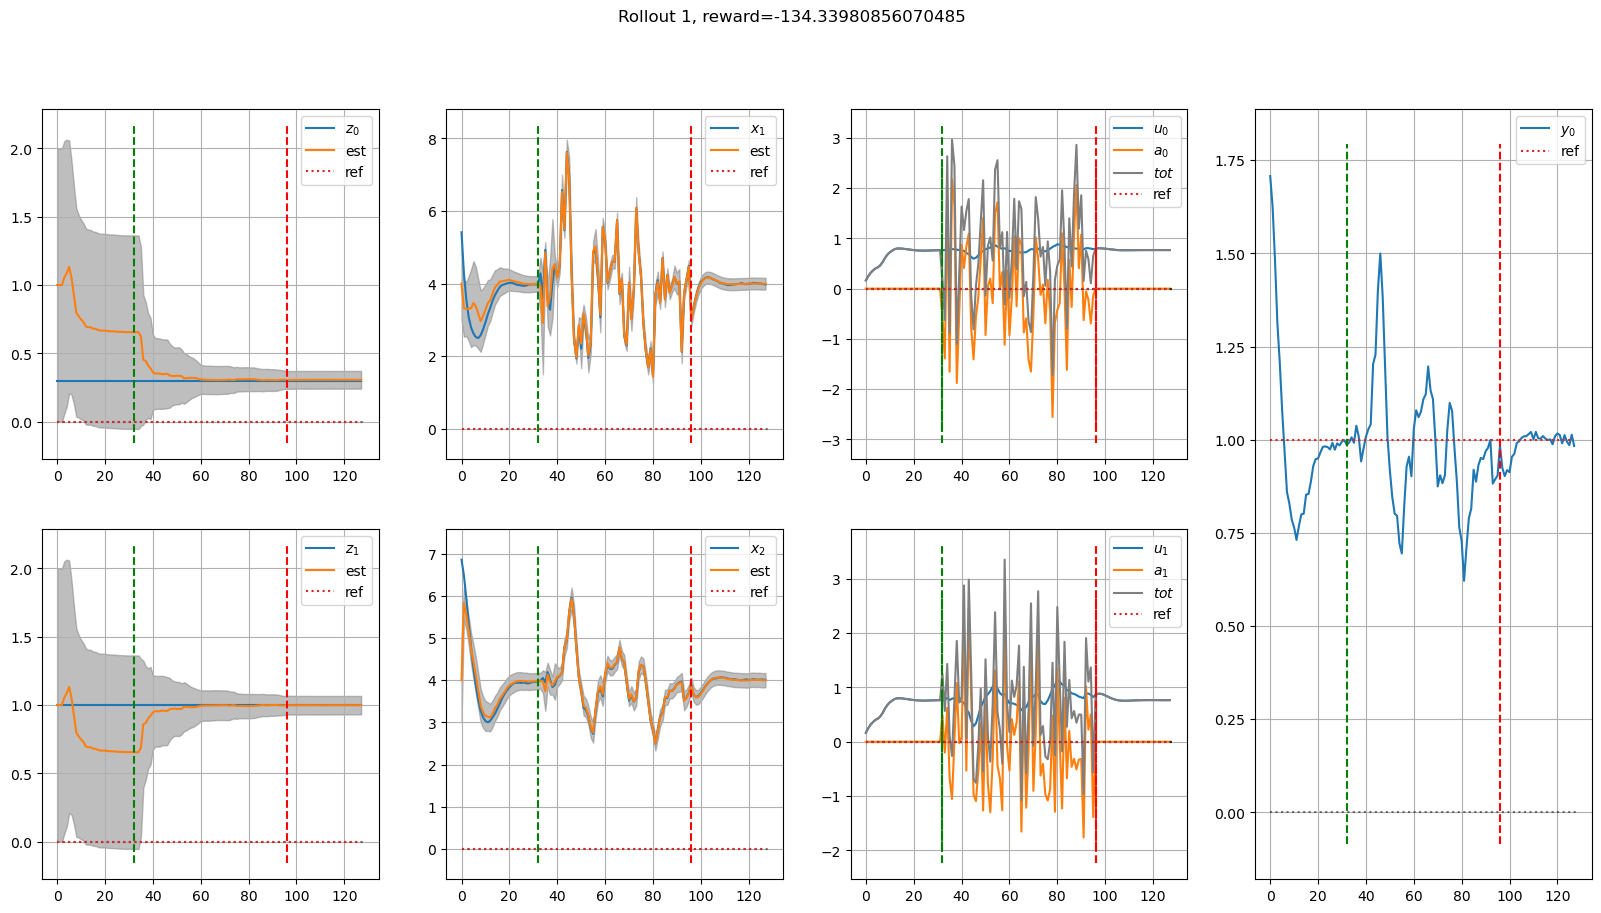

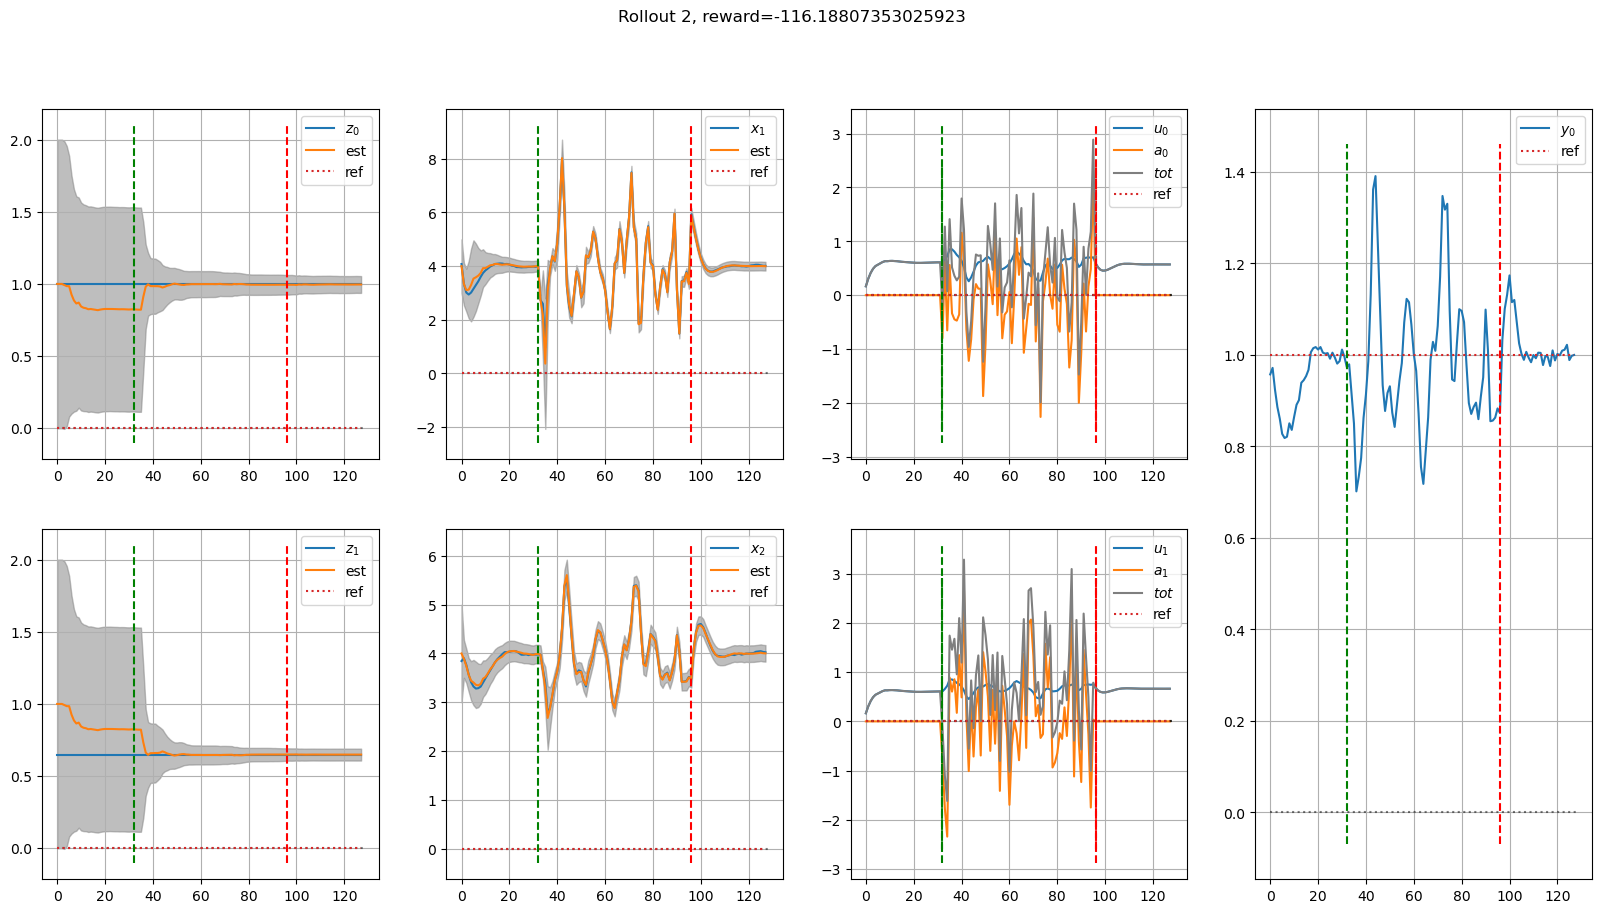

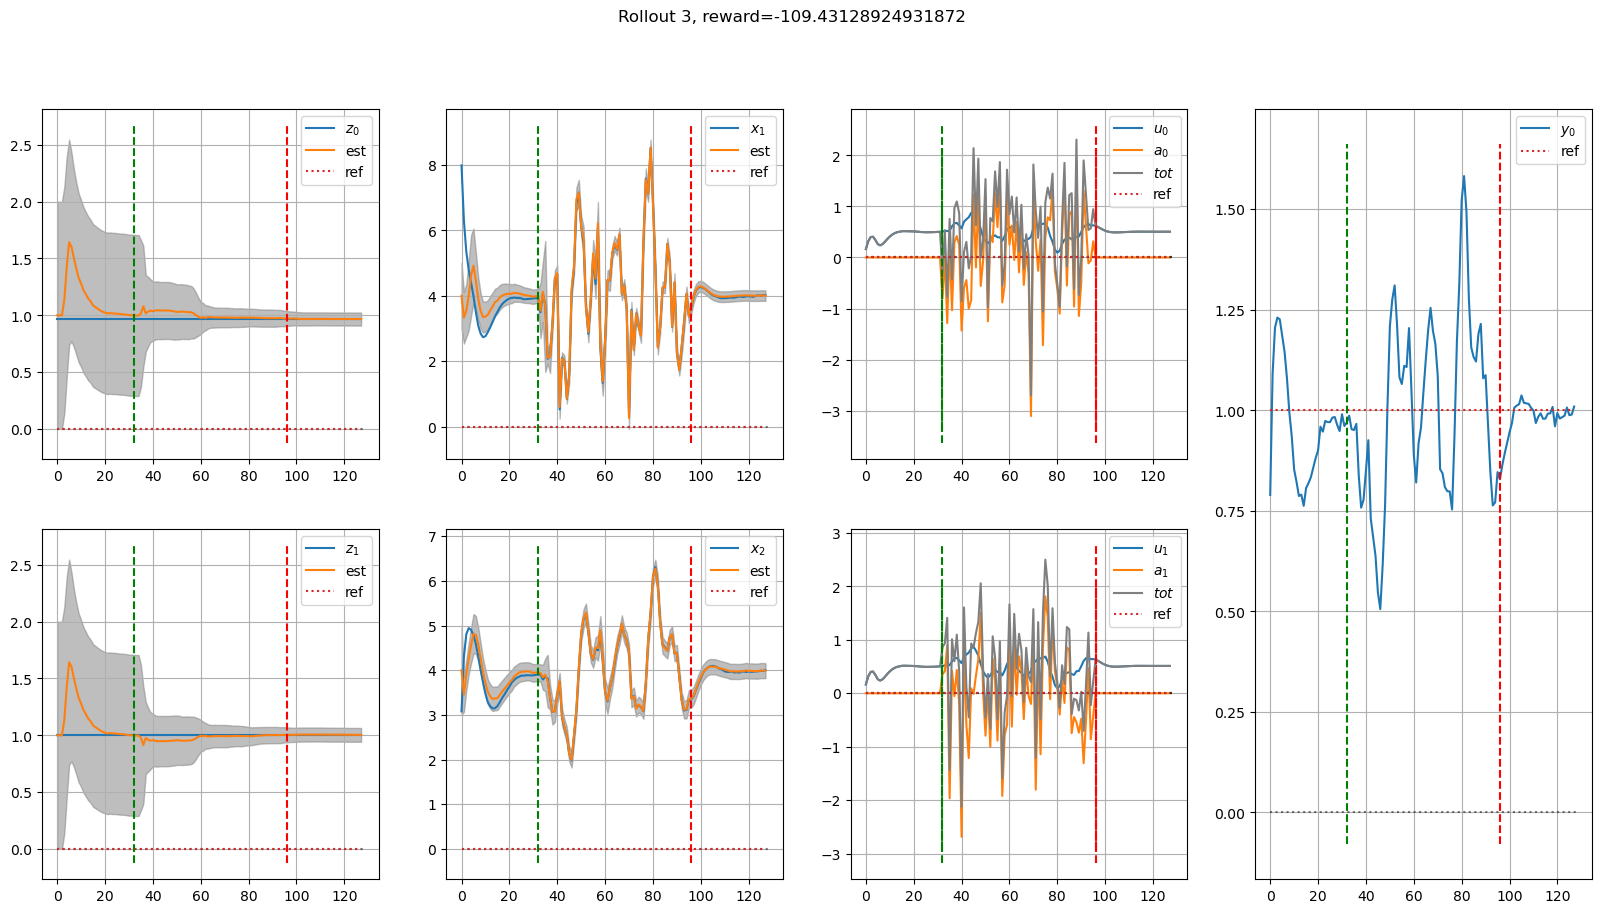

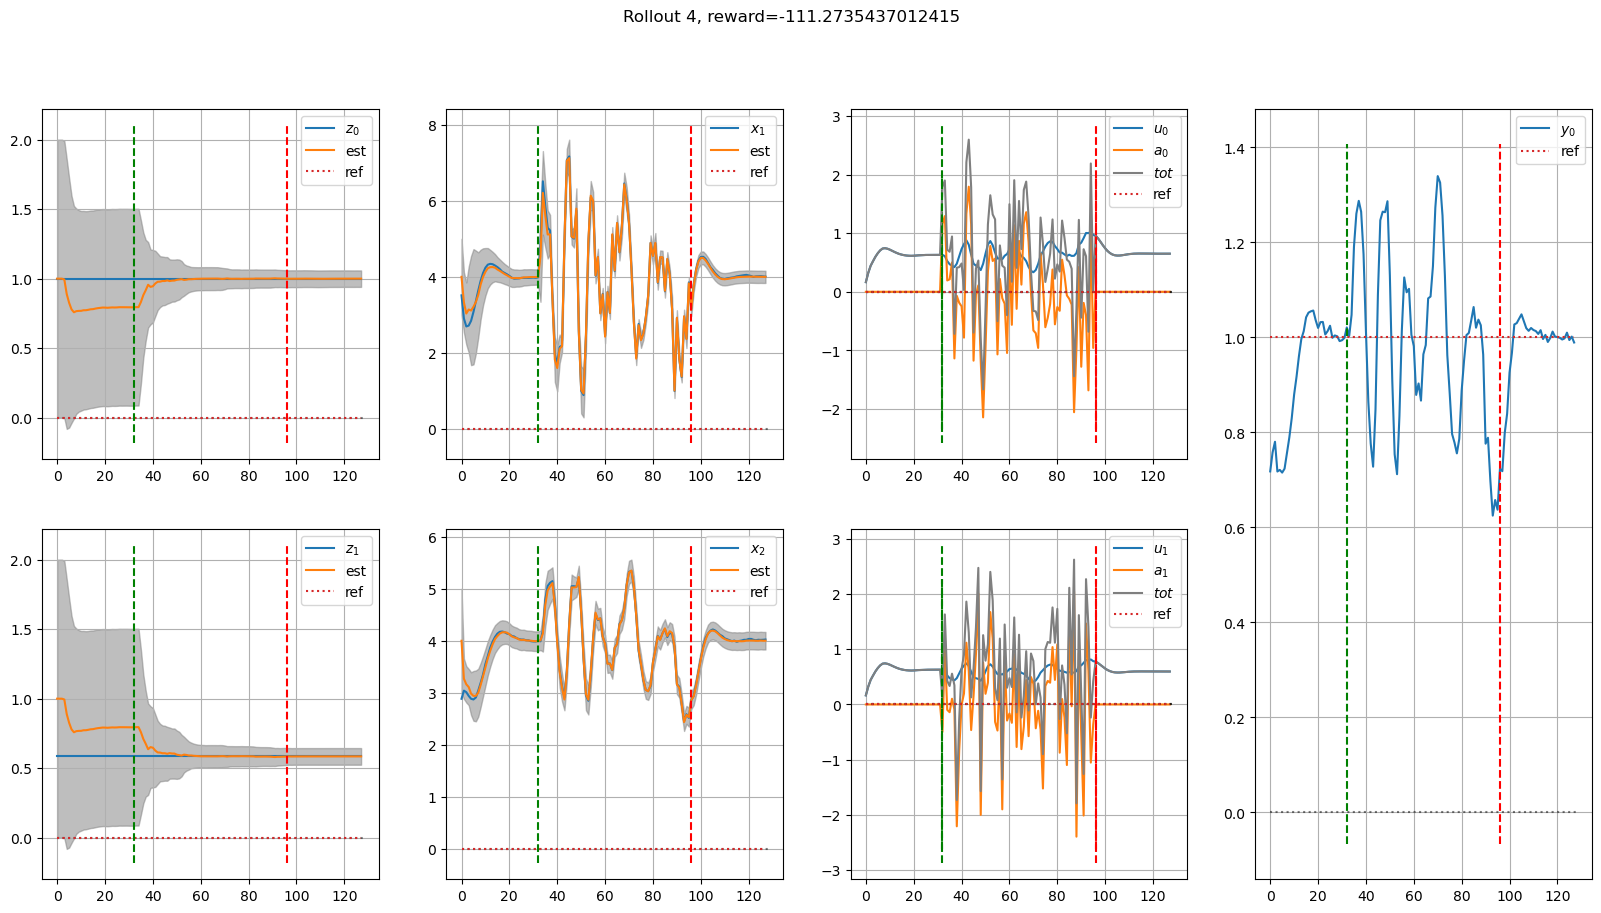

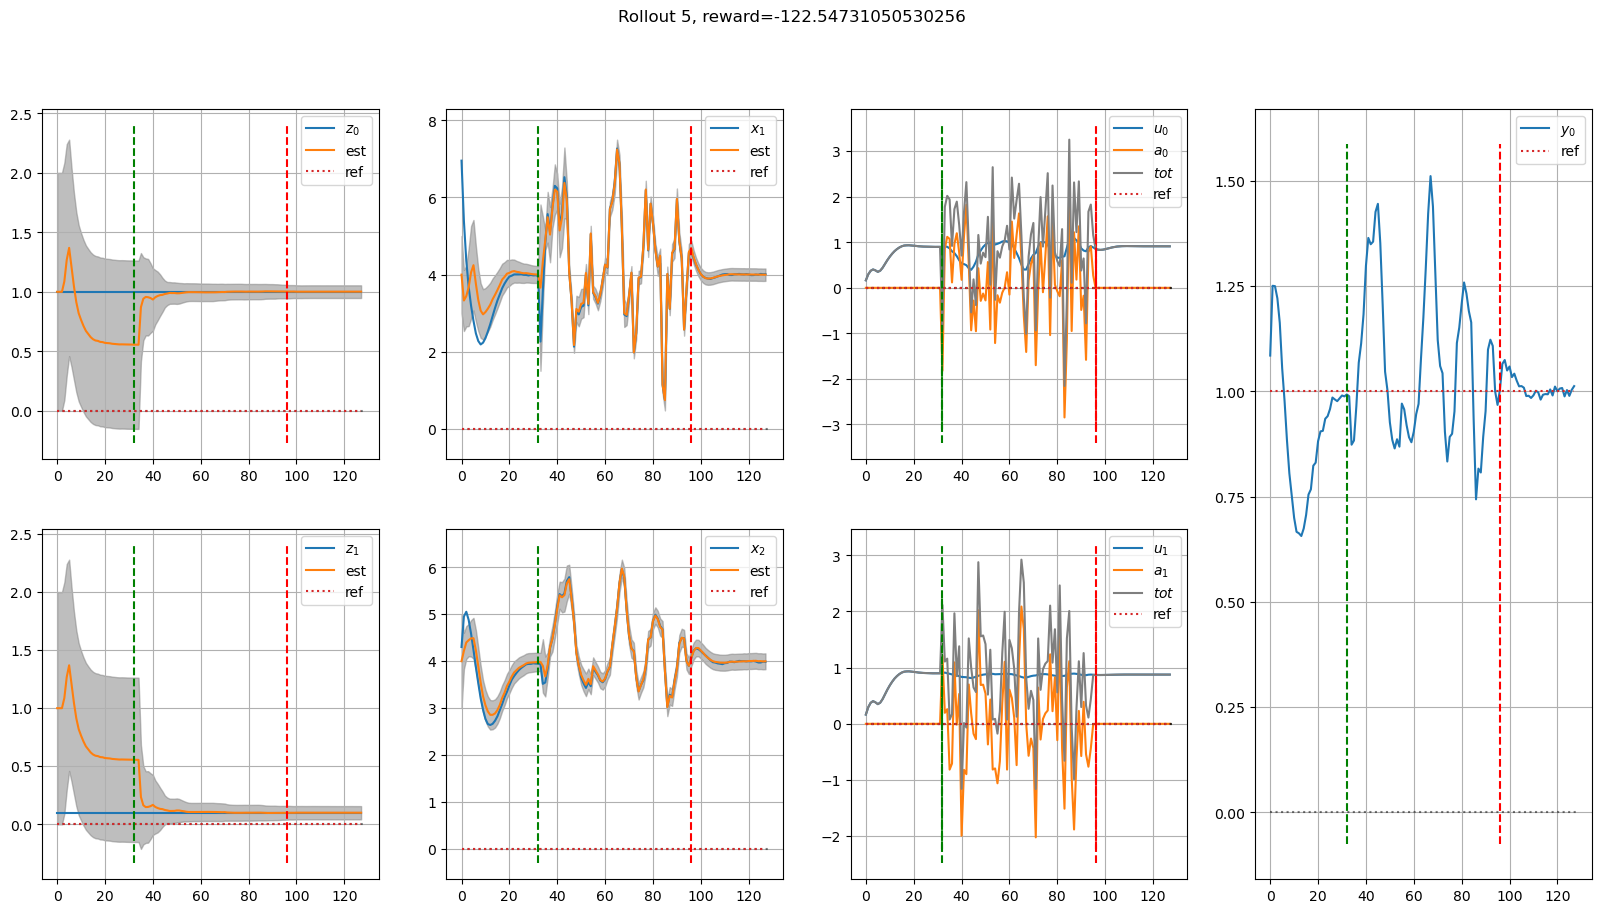

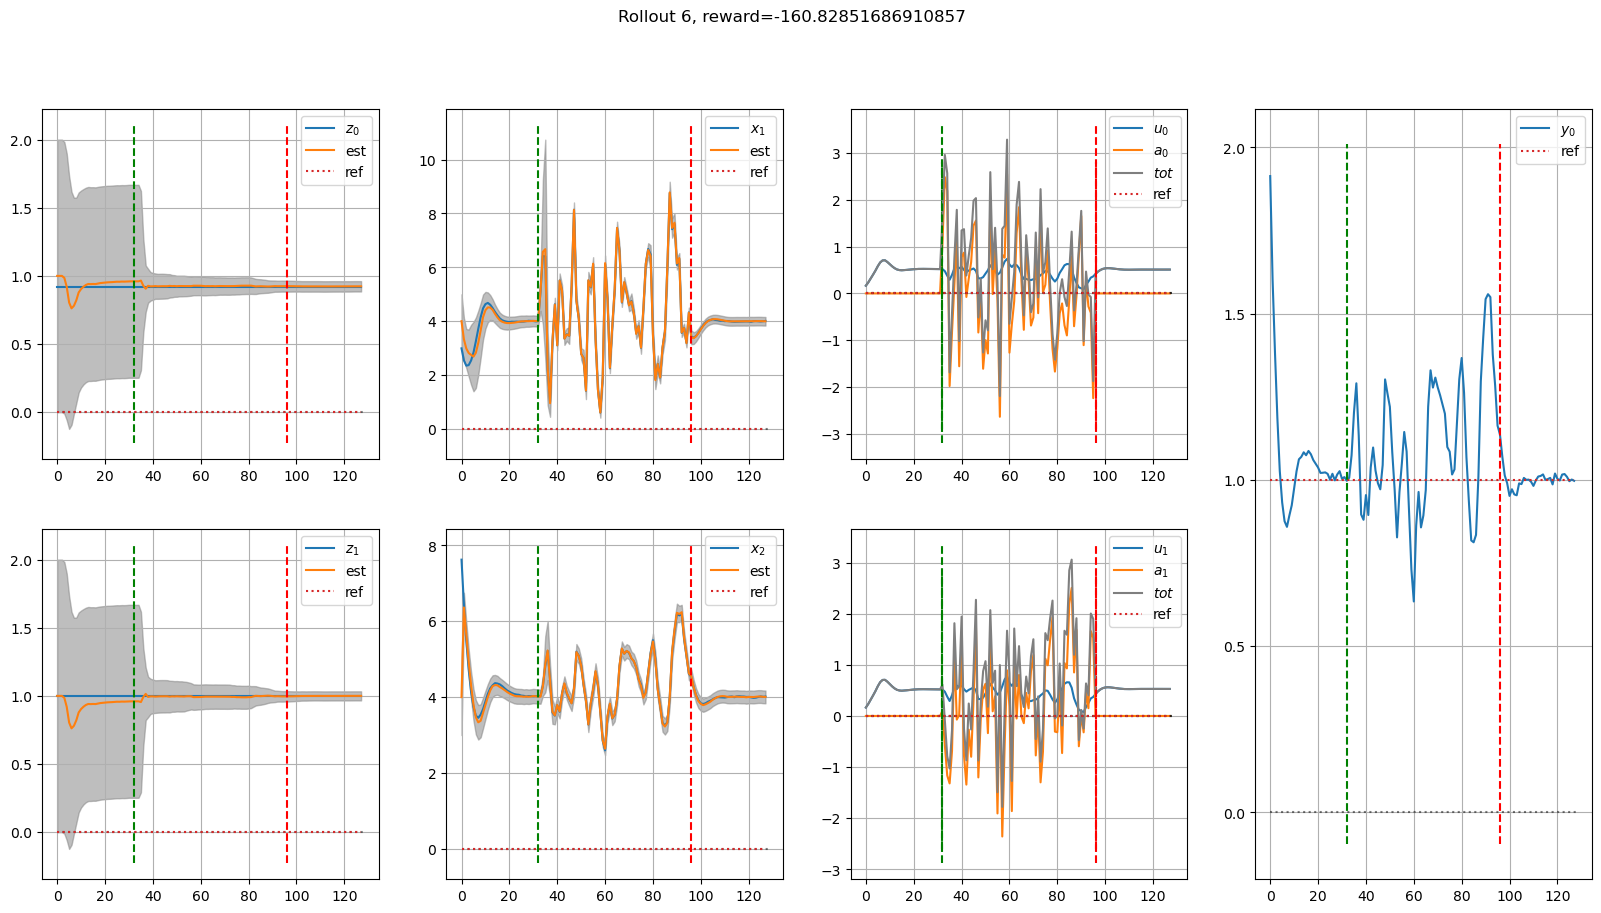

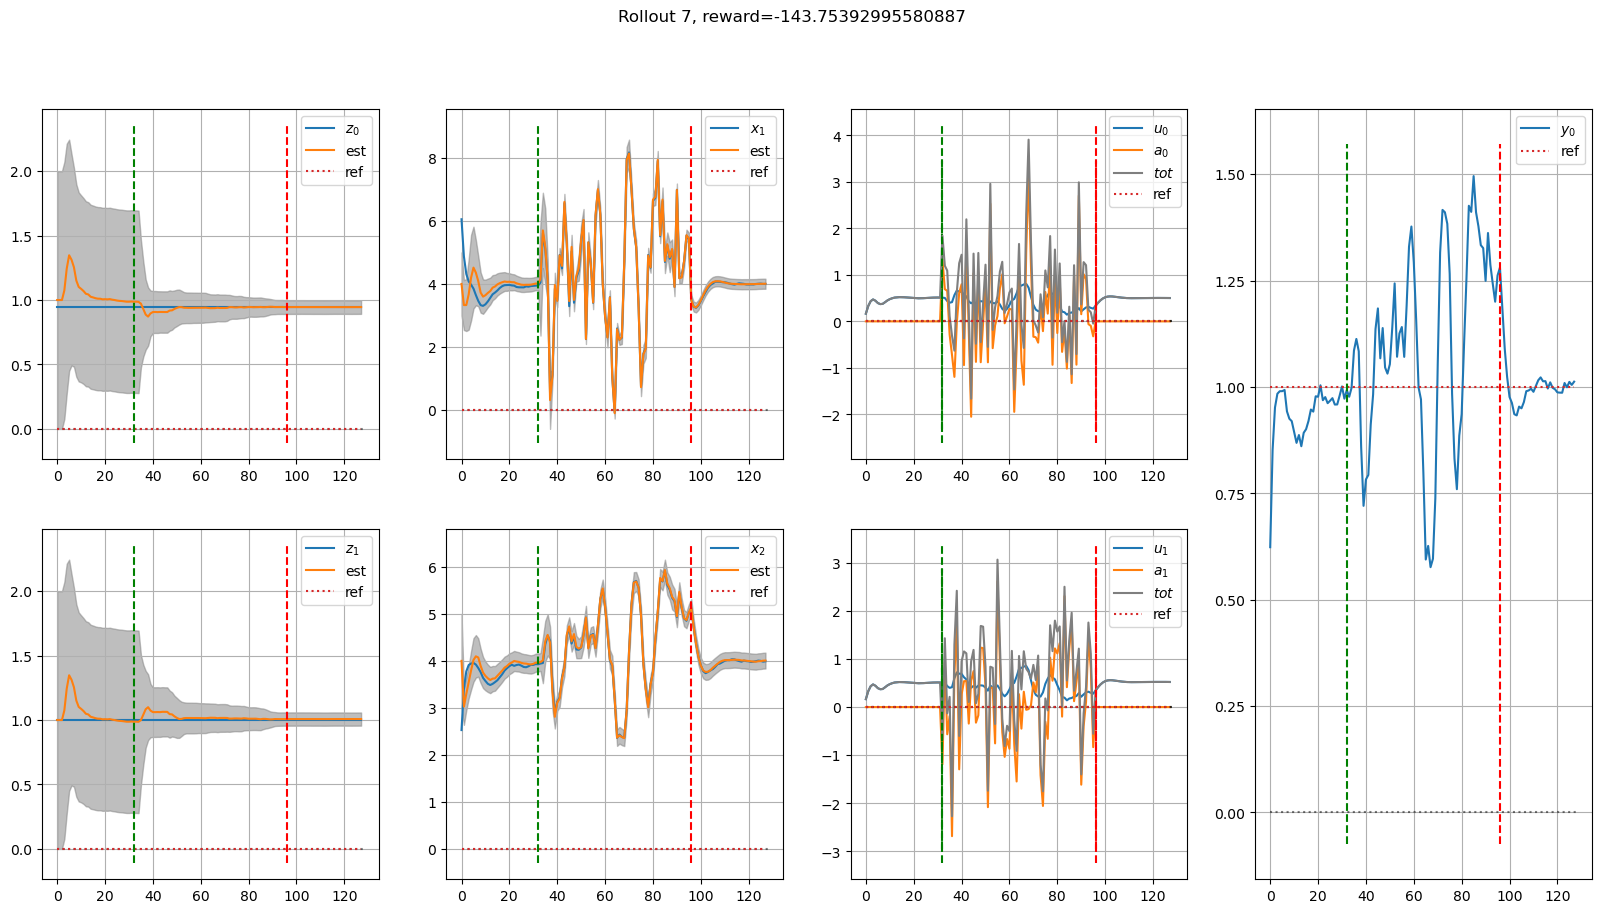

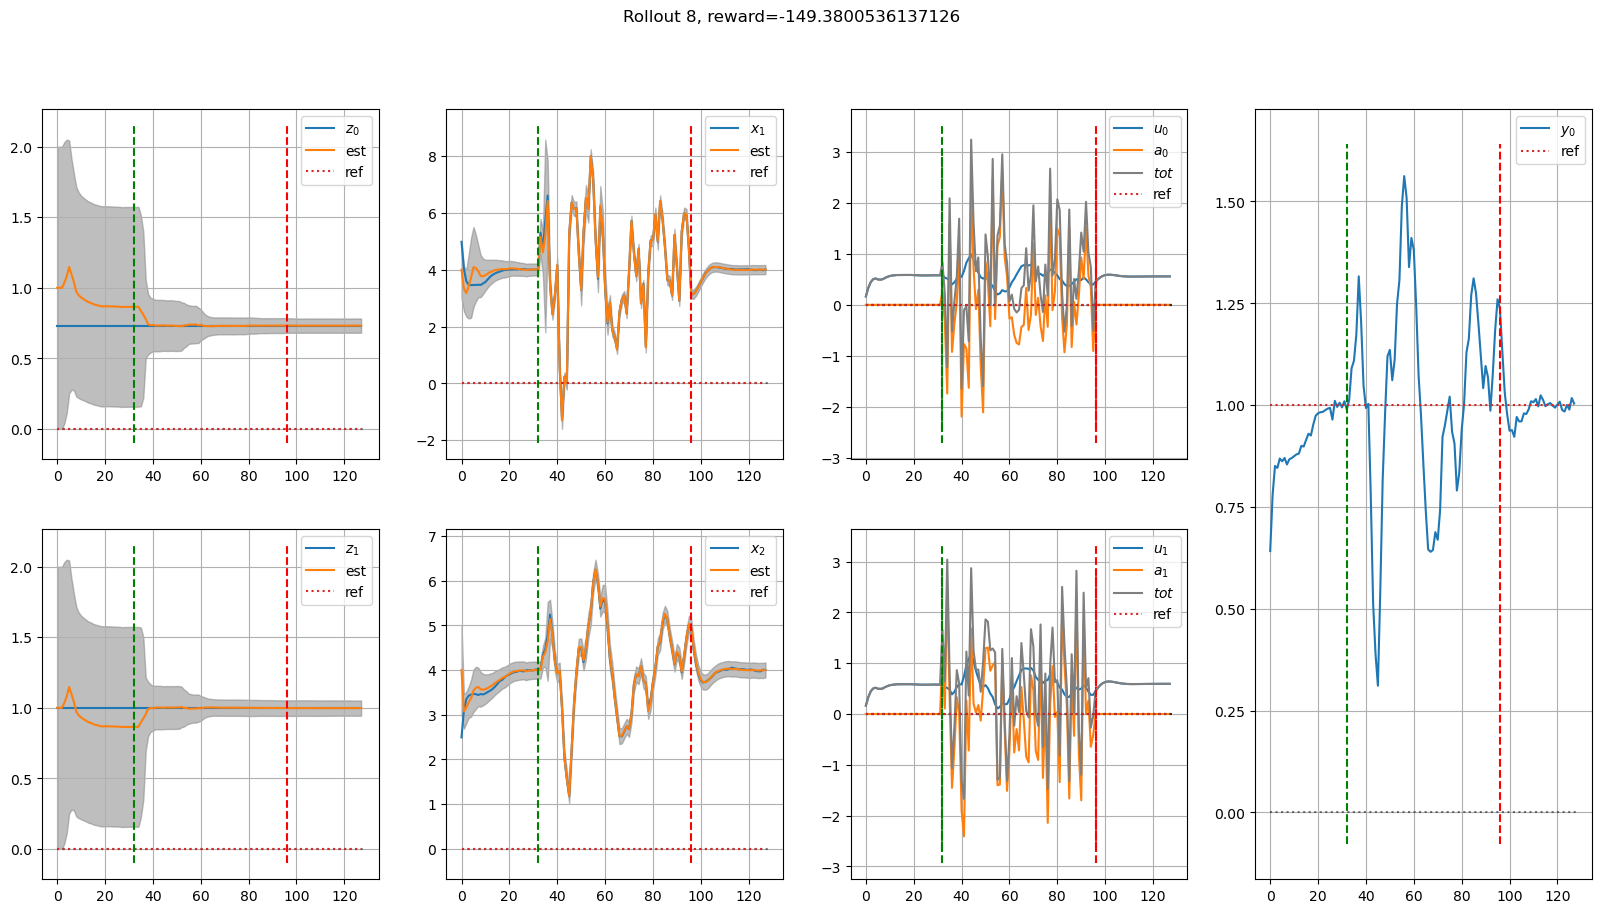

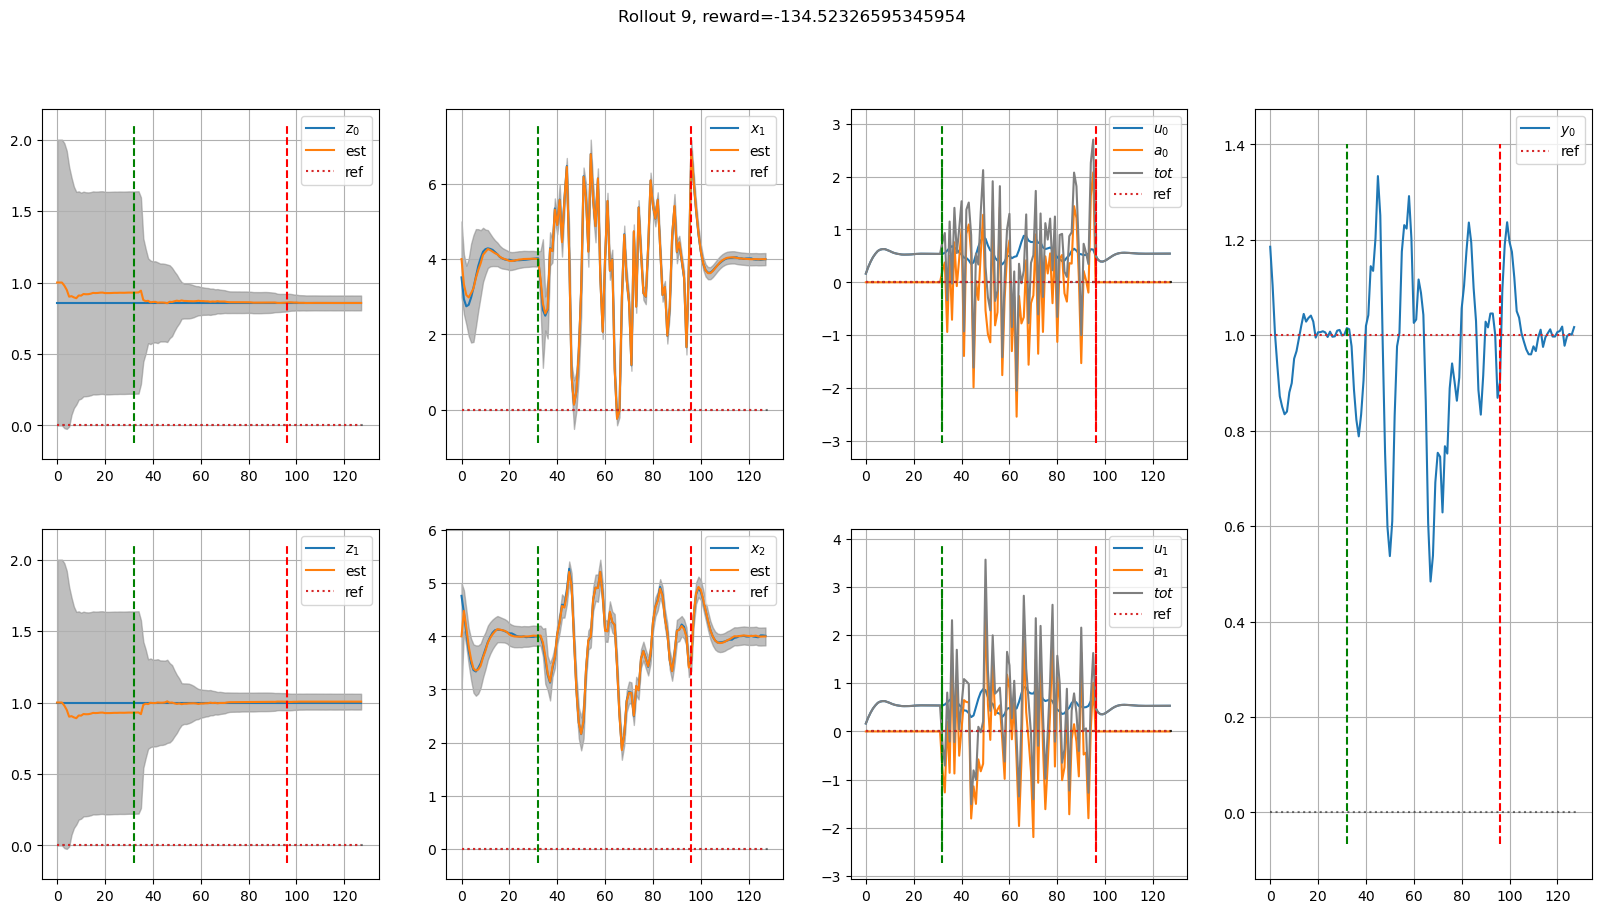

In [4]:
for i in range(10):
    rollout, out = env.rollout(trainer.policy, 128)
    env.render(out, title=f"Rollout {i}, reward={rollout.r.sum()}")

# Train

In [5]:
logger = trainer.train(epochs=1000, episode_length=128)
nnx.display(trainer)

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [03:56<00:00,  4.22it/s, V=-1.19, loss_pi=0.0337, loss_vf=0.00285, reward=-.0471]


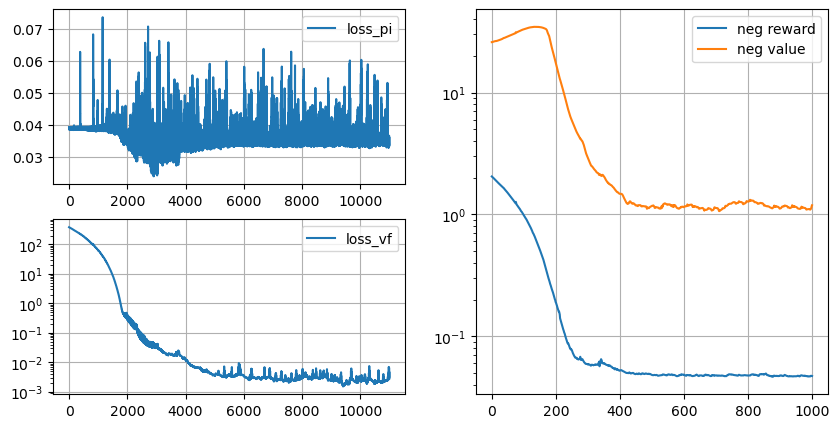

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(2, 2, 1)
plt.plot(logger["loss_pi"], label='loss_pi') 
plt.legend()
plt.grid()
plt.subplot(2, 2, 3)
plt.semilogy(logger["loss_vf"], label='loss_vf')
plt.legend()
plt.grid()
plt.subplot(1, 2, 2)
plt.semilogy(-logger["reward"].mean(axis=-1).mean(axis=-1), label='neg reward')
plt.semilogy(-logger["V"].mean(axis=-1).mean(axis=-1), label='neg value')
plt.legend()
plt.grid()
plt.show()

# Trained Policy

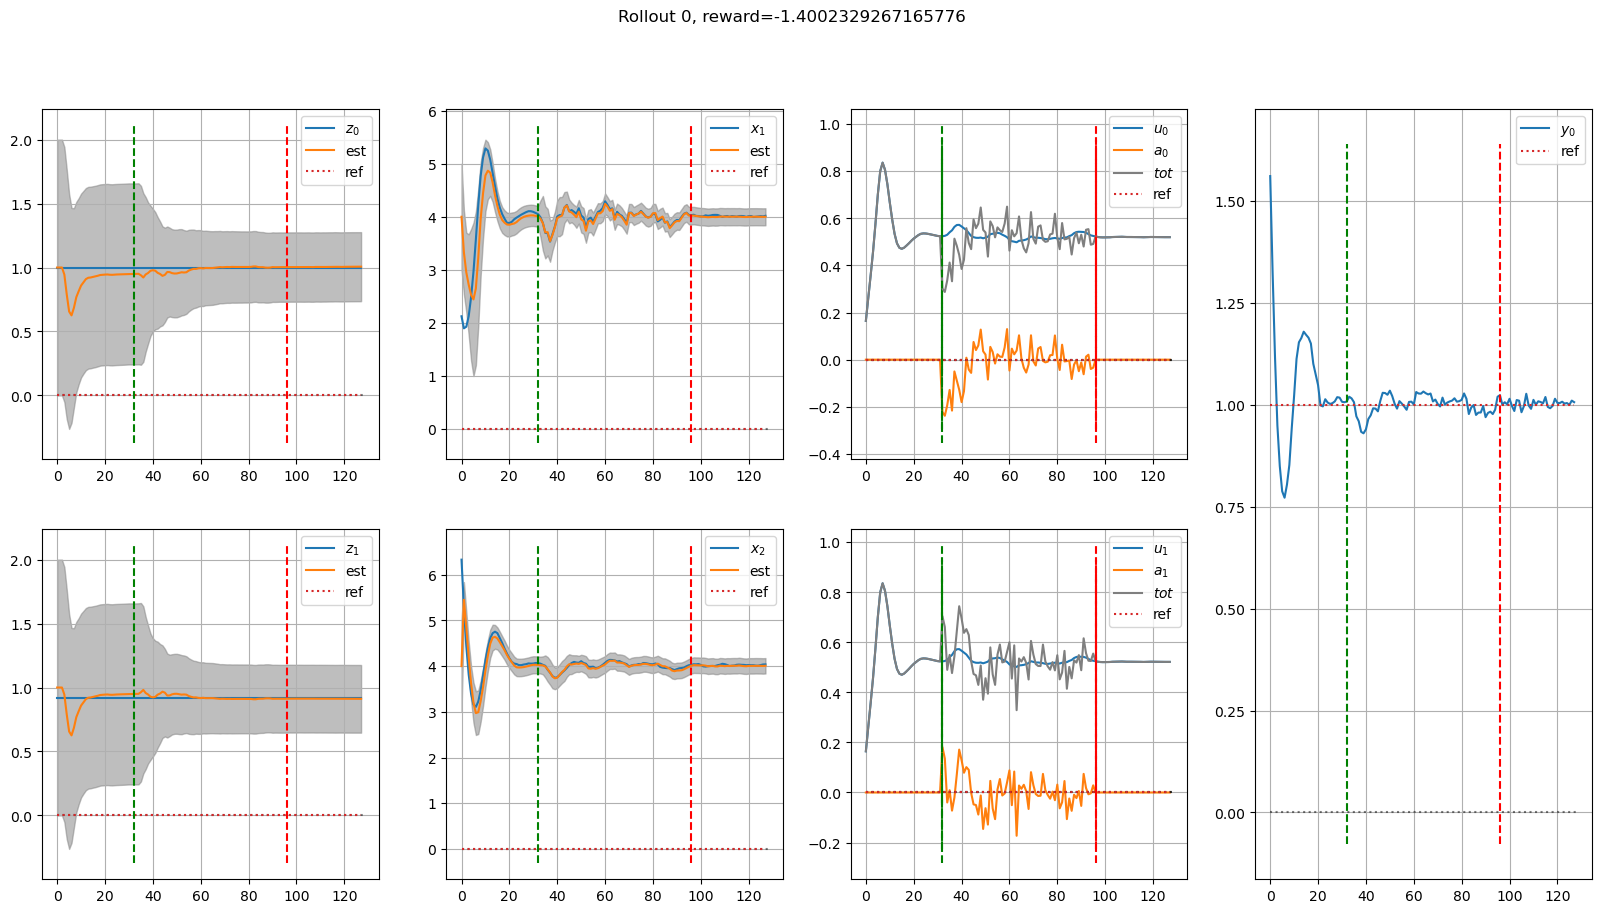

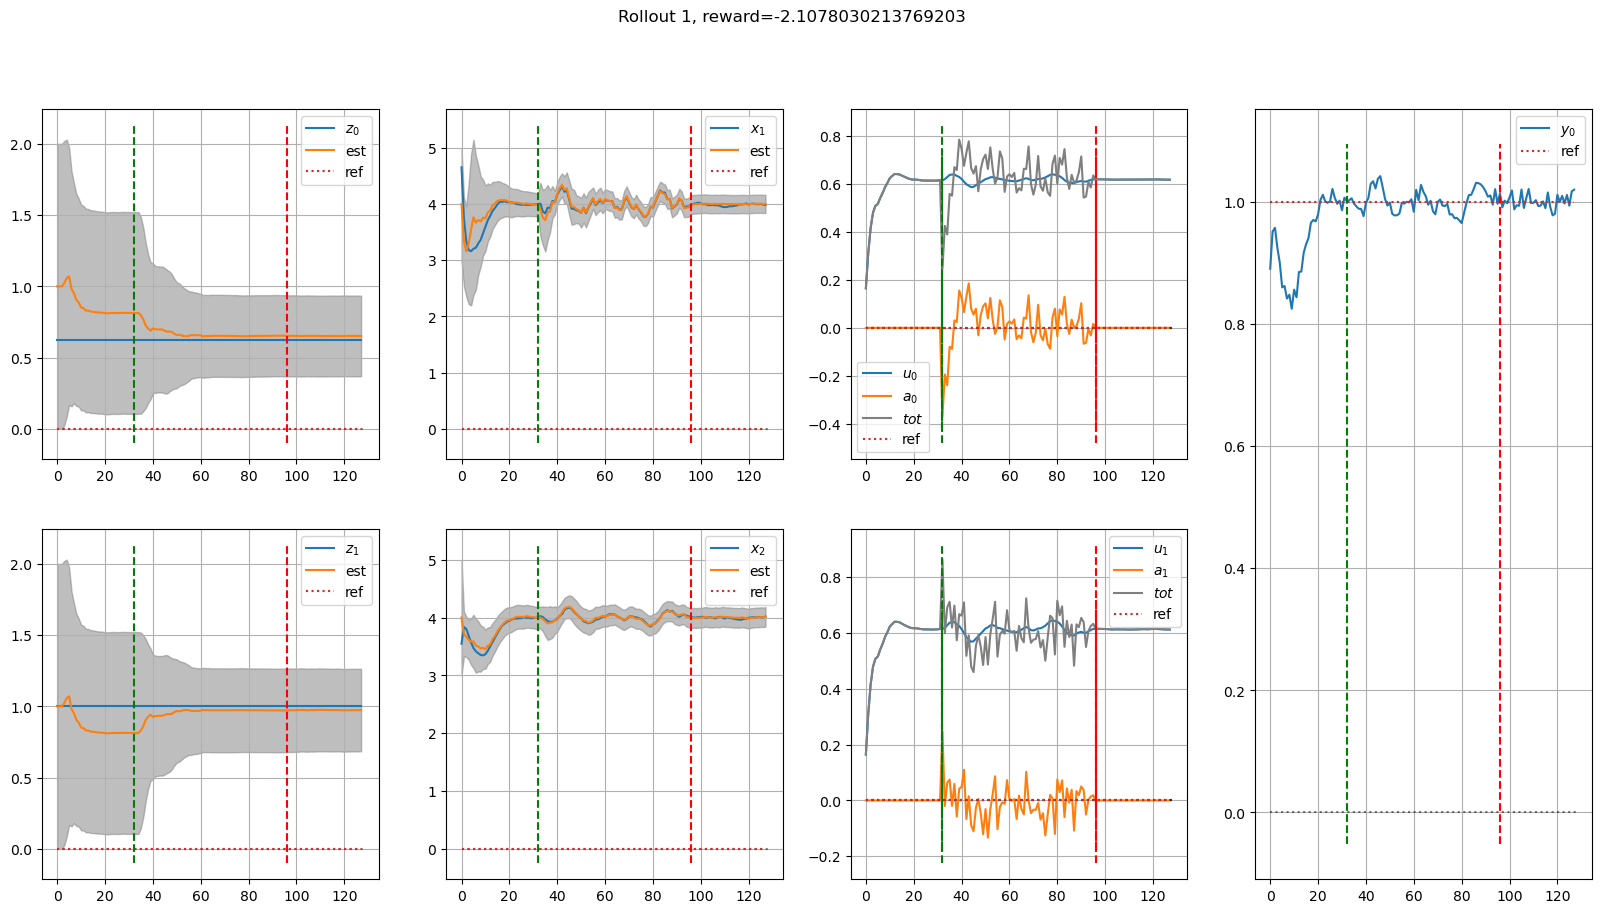

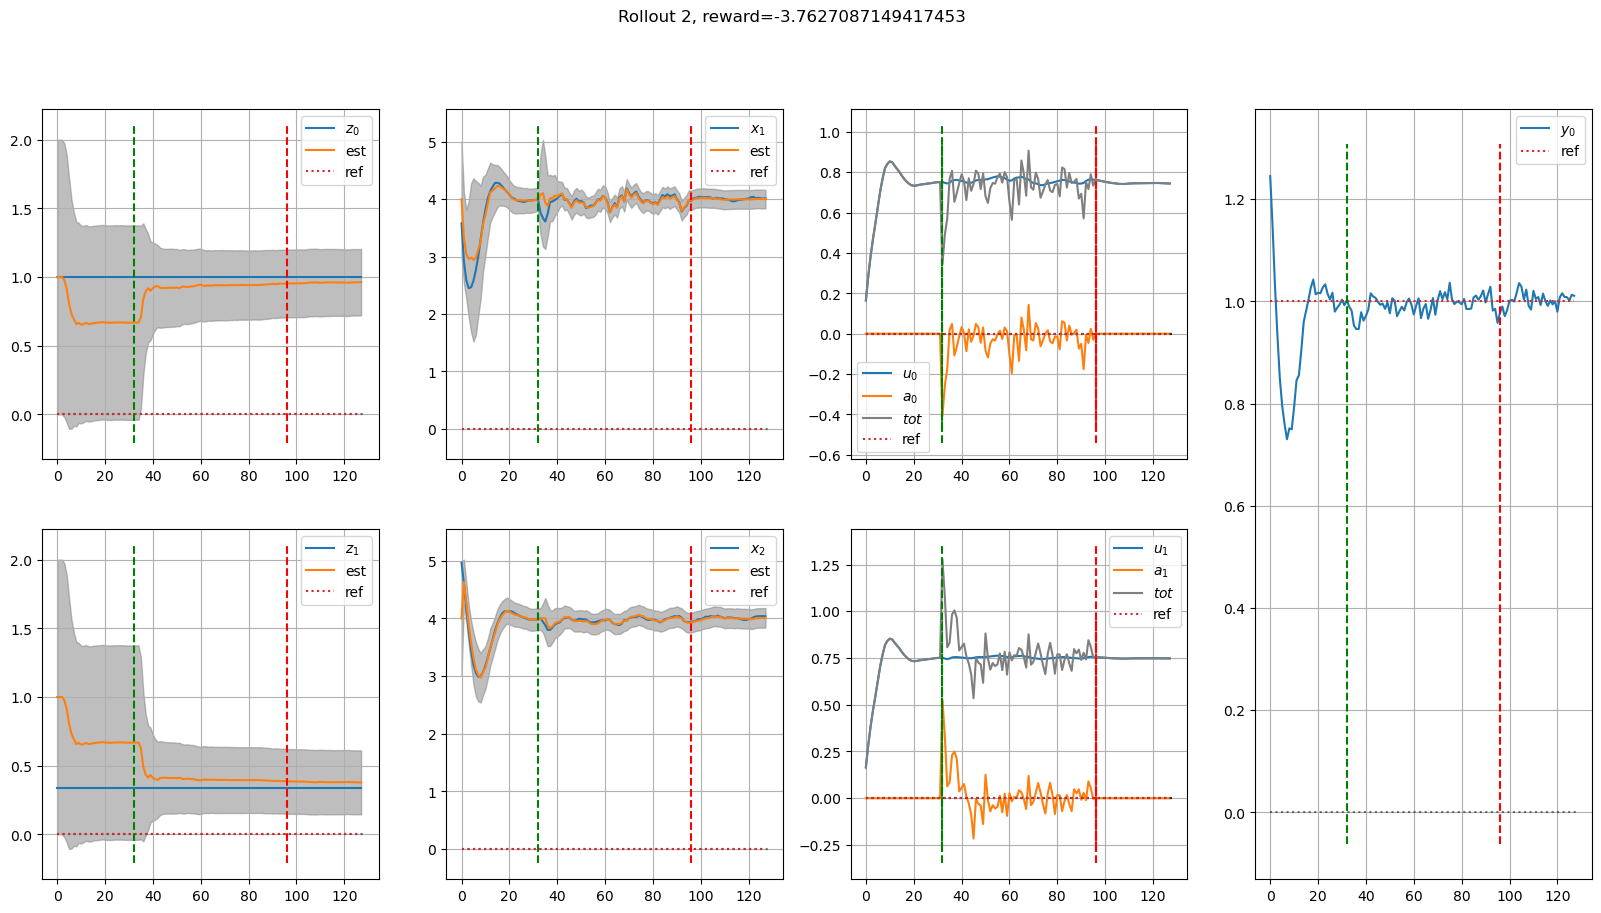

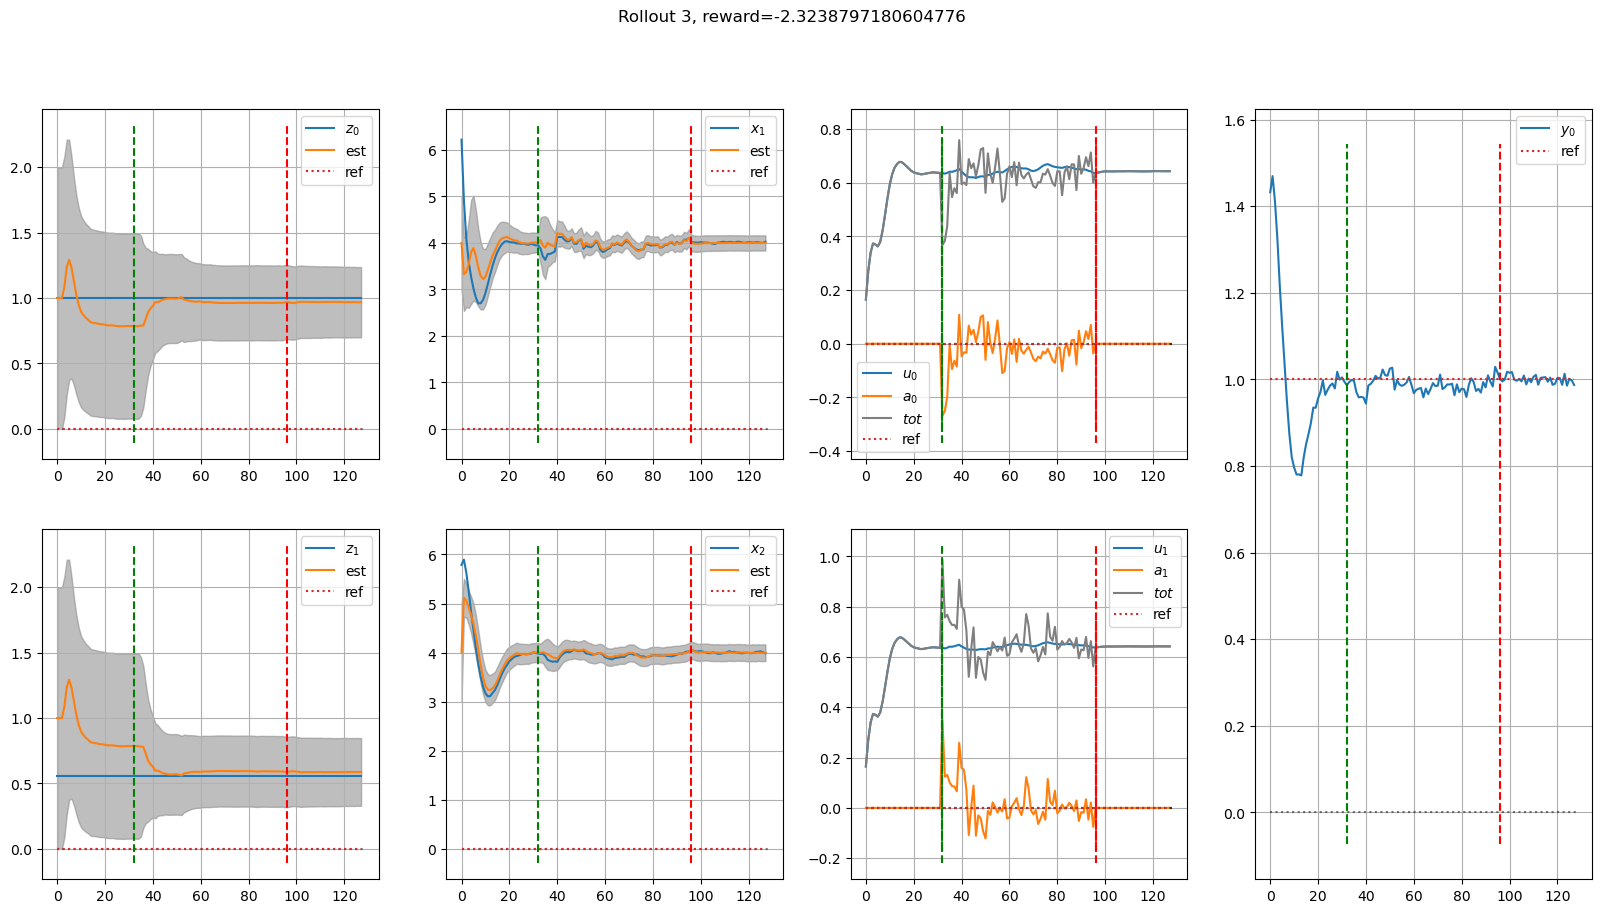

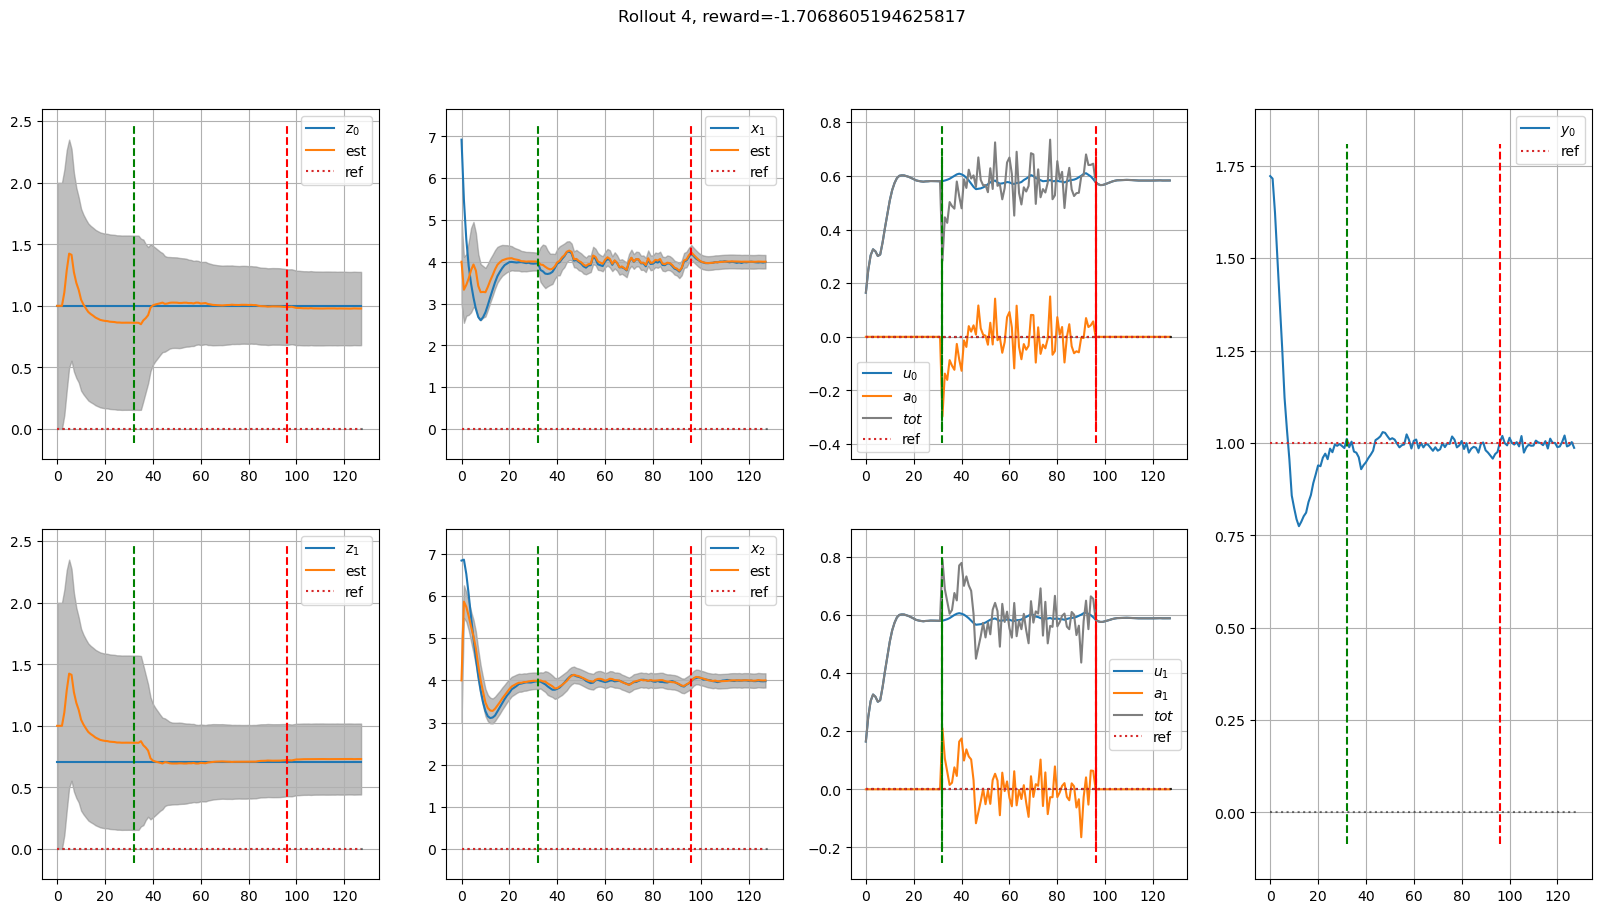

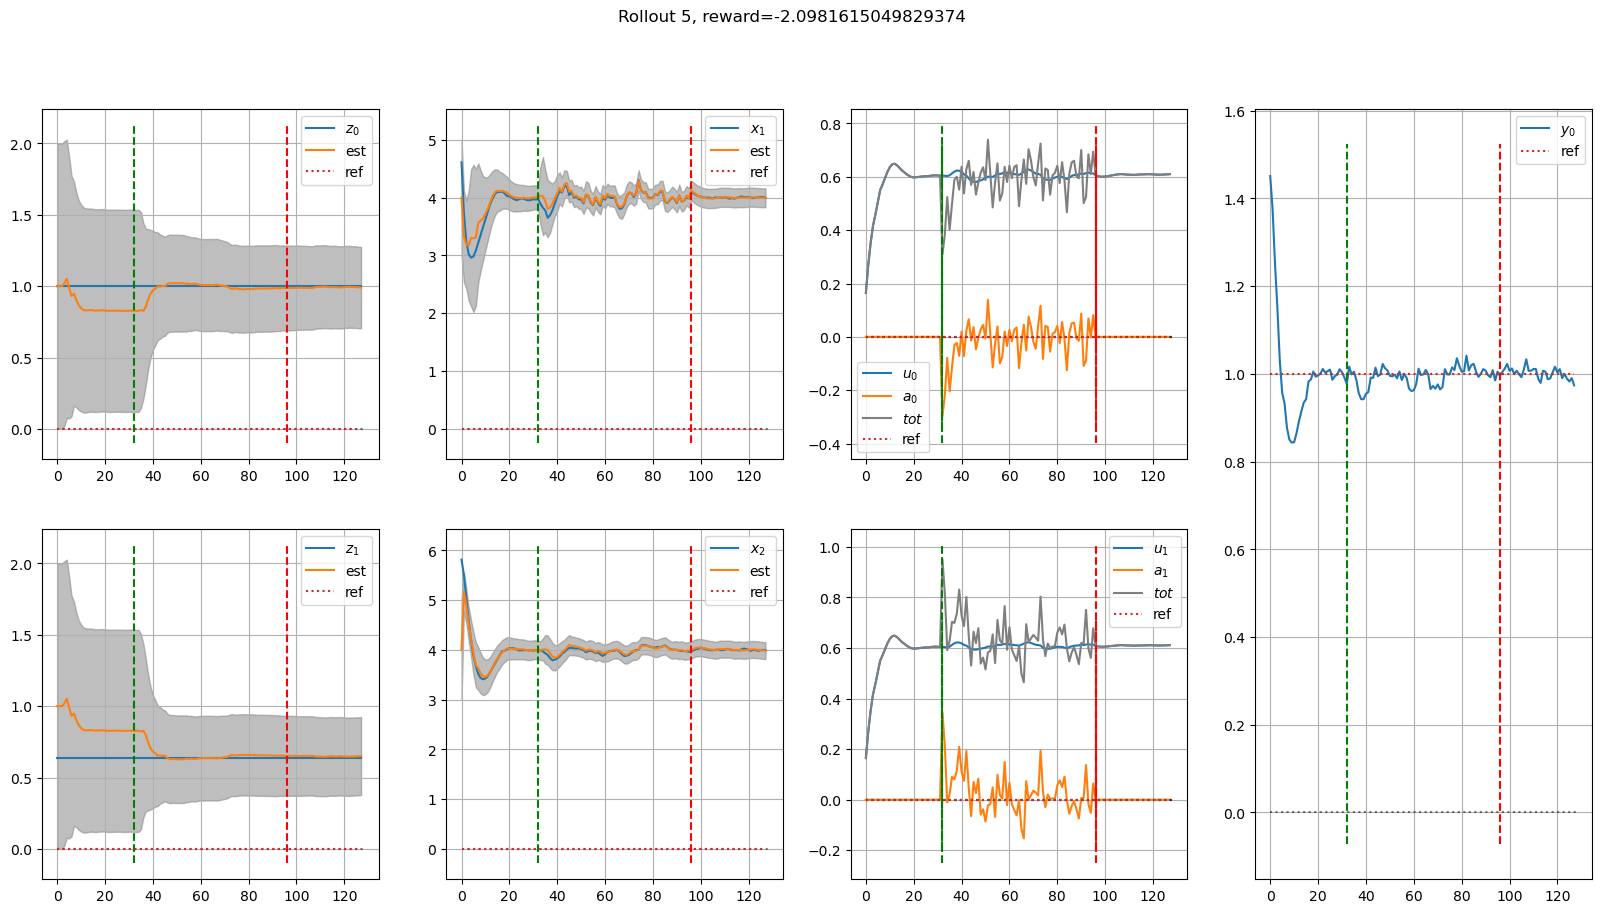

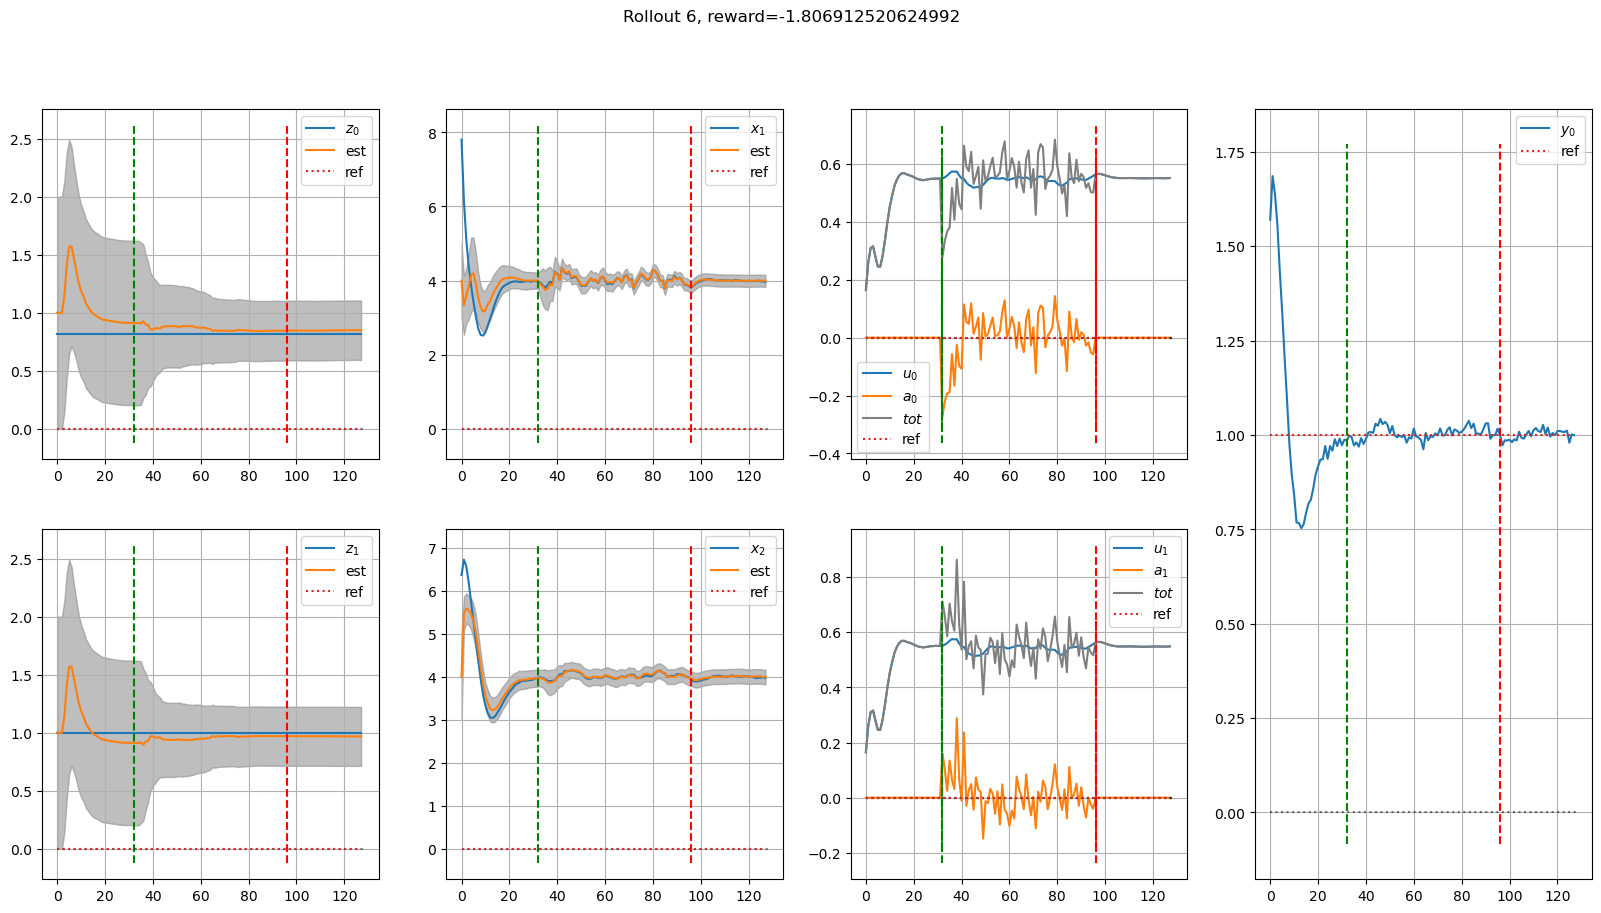

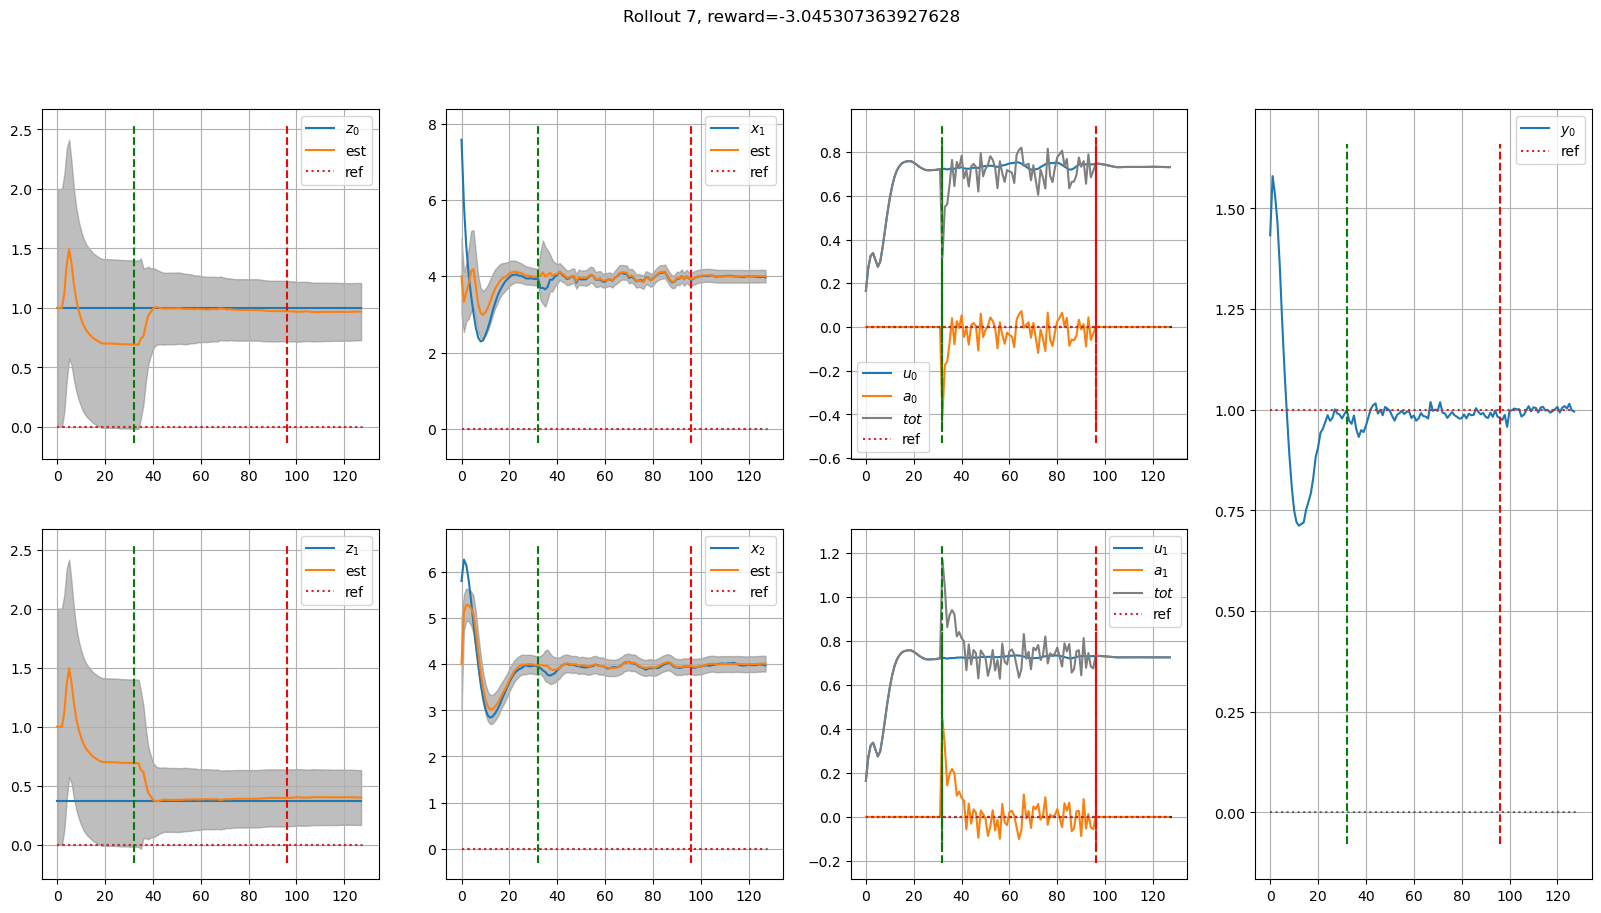

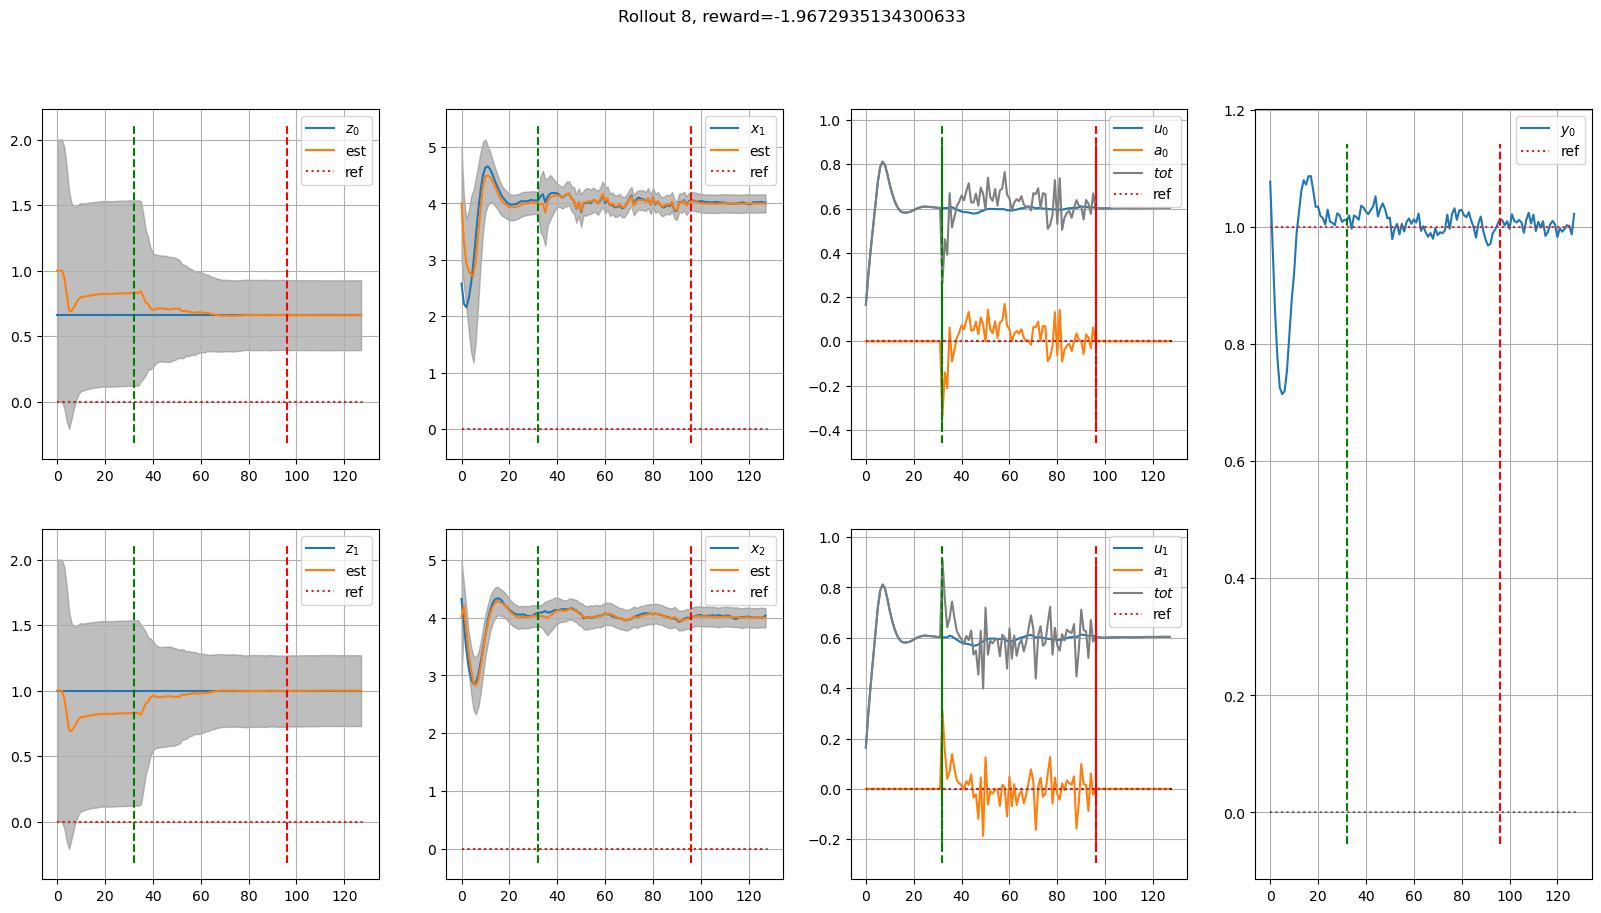

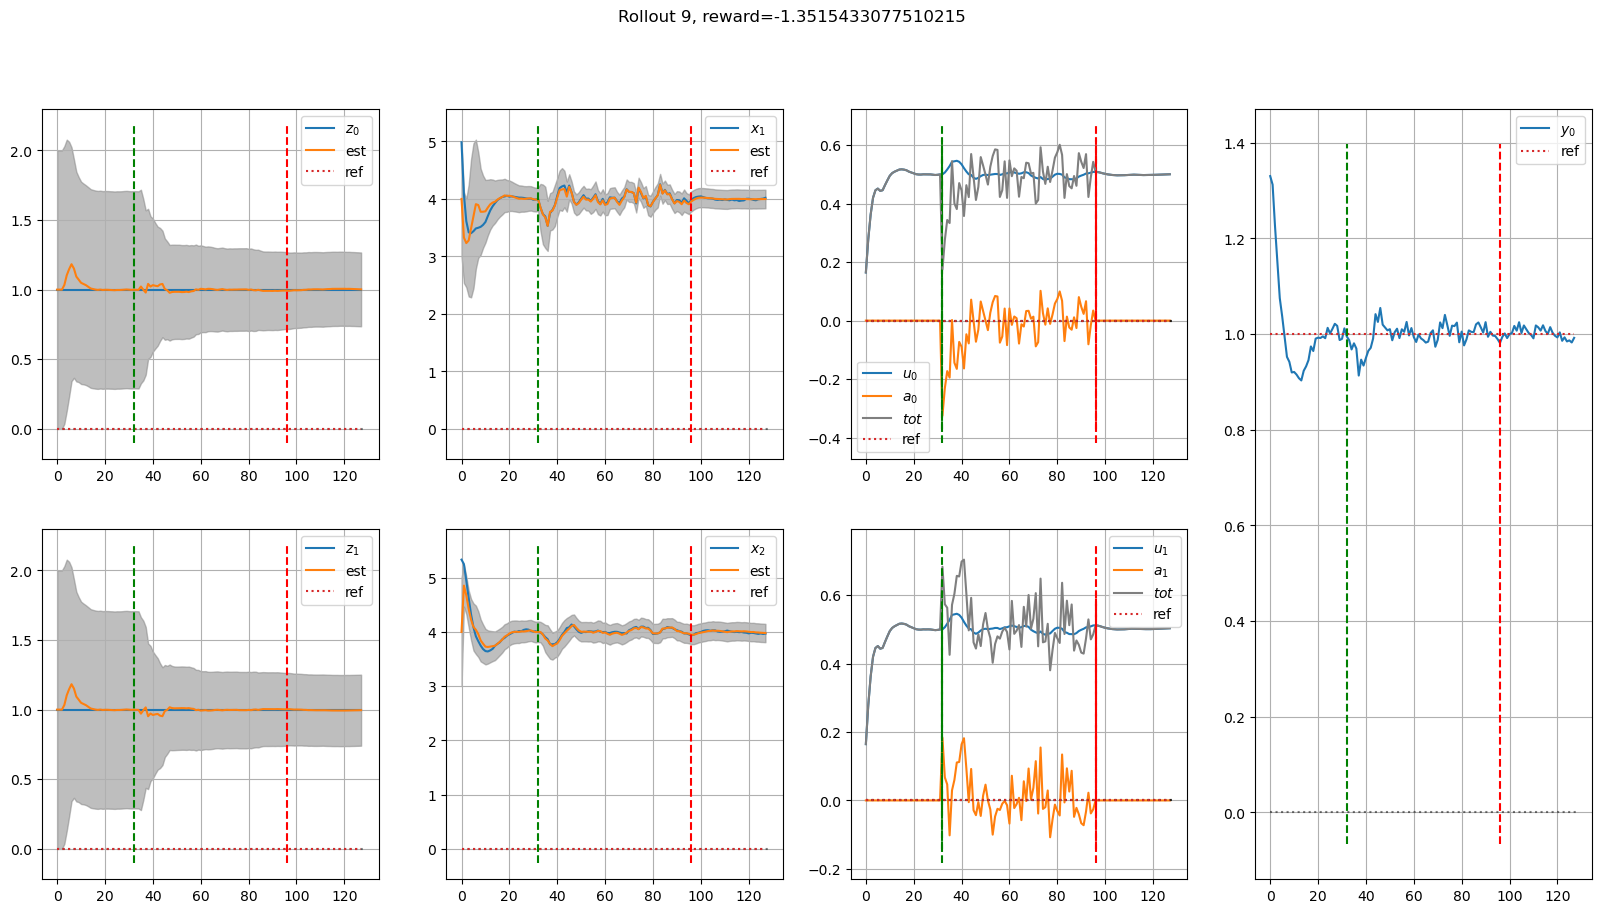

In [7]:
for i in range(10):
    rollout, out = env.rollout(trainer.policy, 128)
    env.render(out, title=f"Rollout {i}, reward={rollout.r.sum()}")

# Trained Deterministic

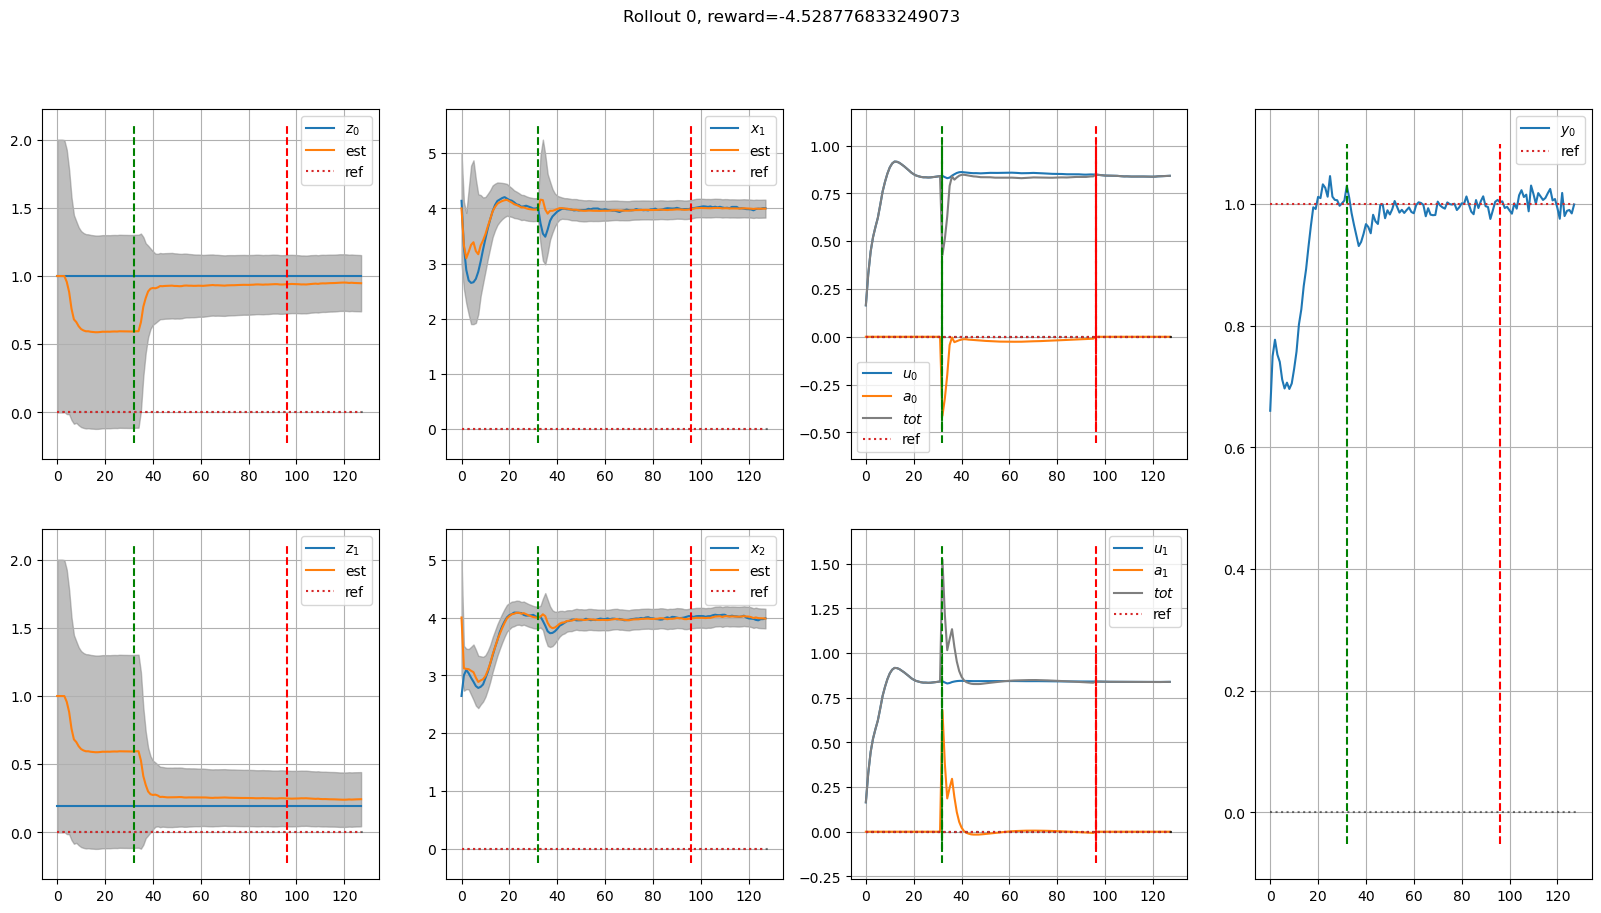

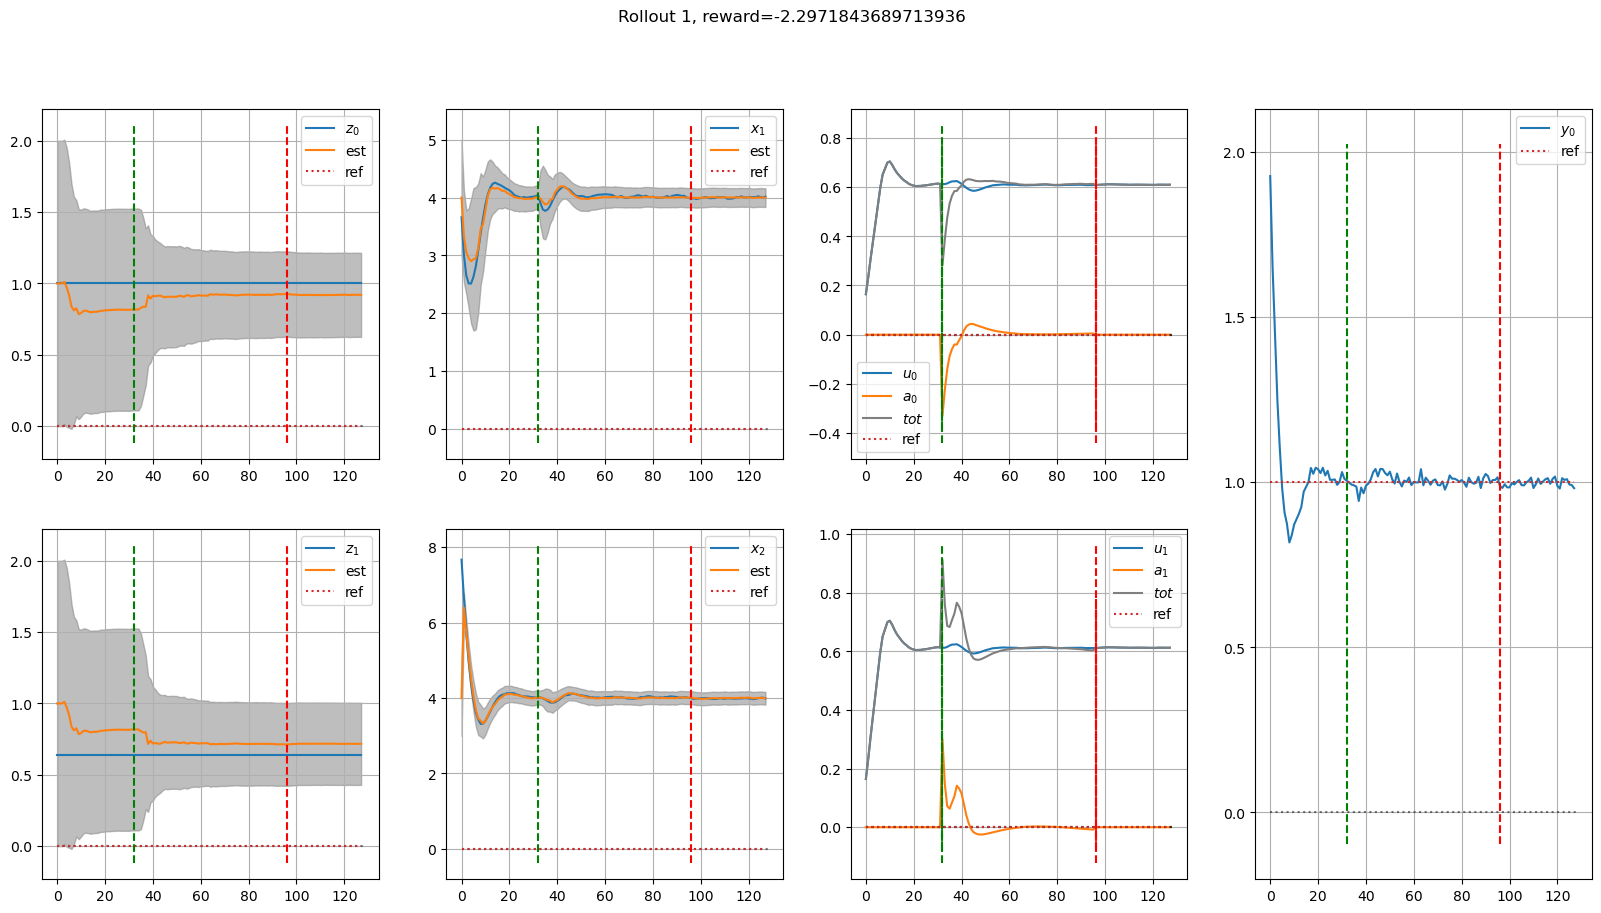

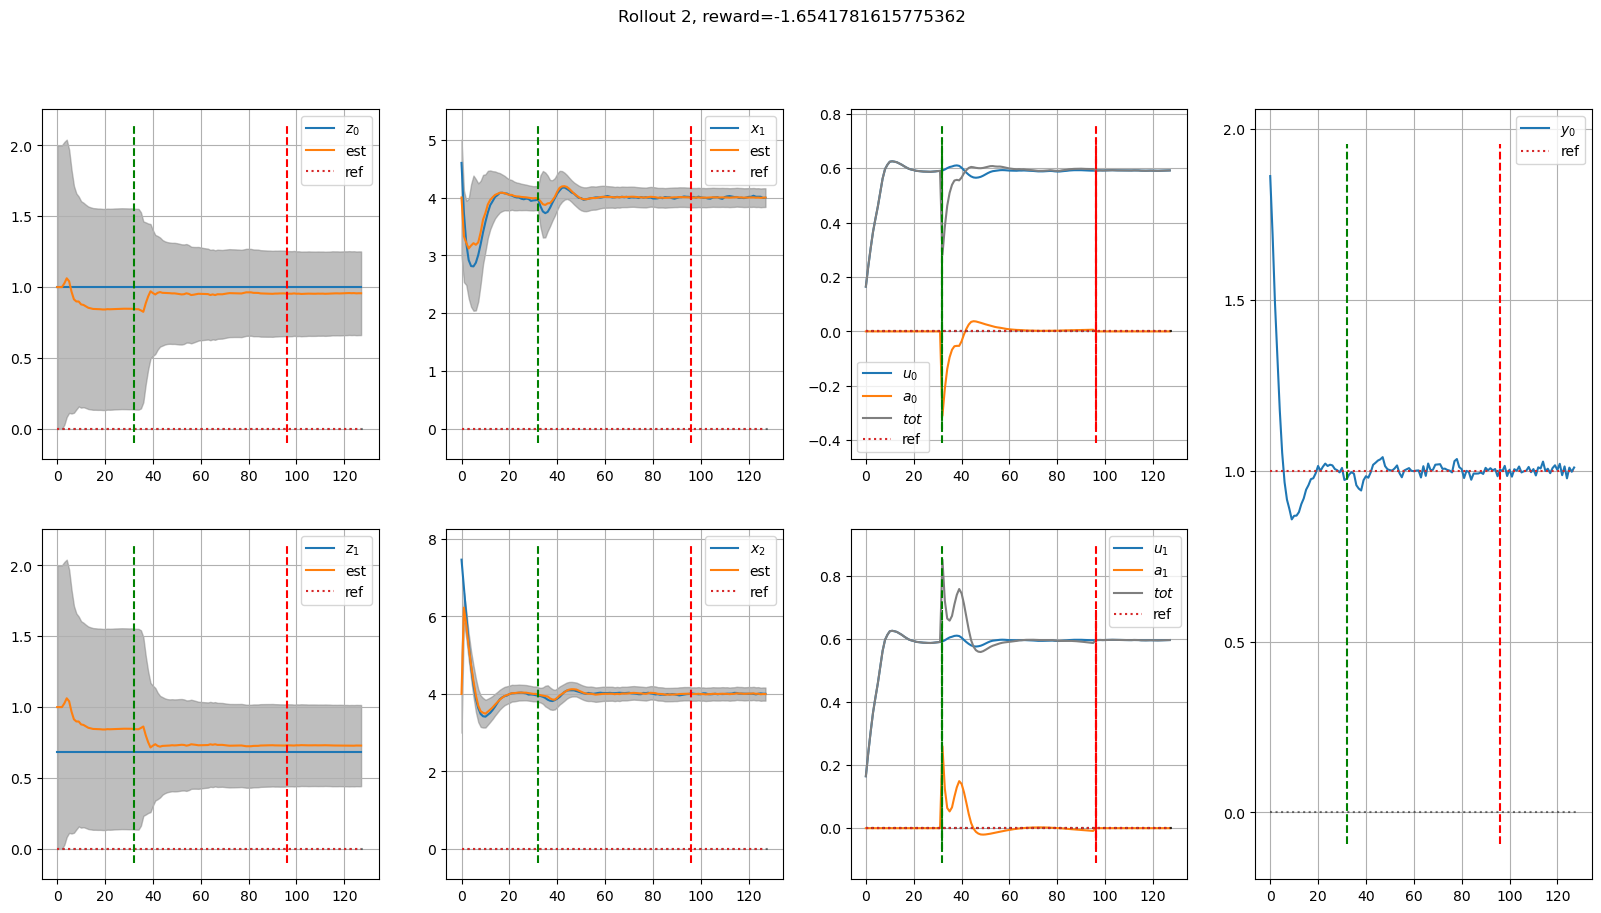

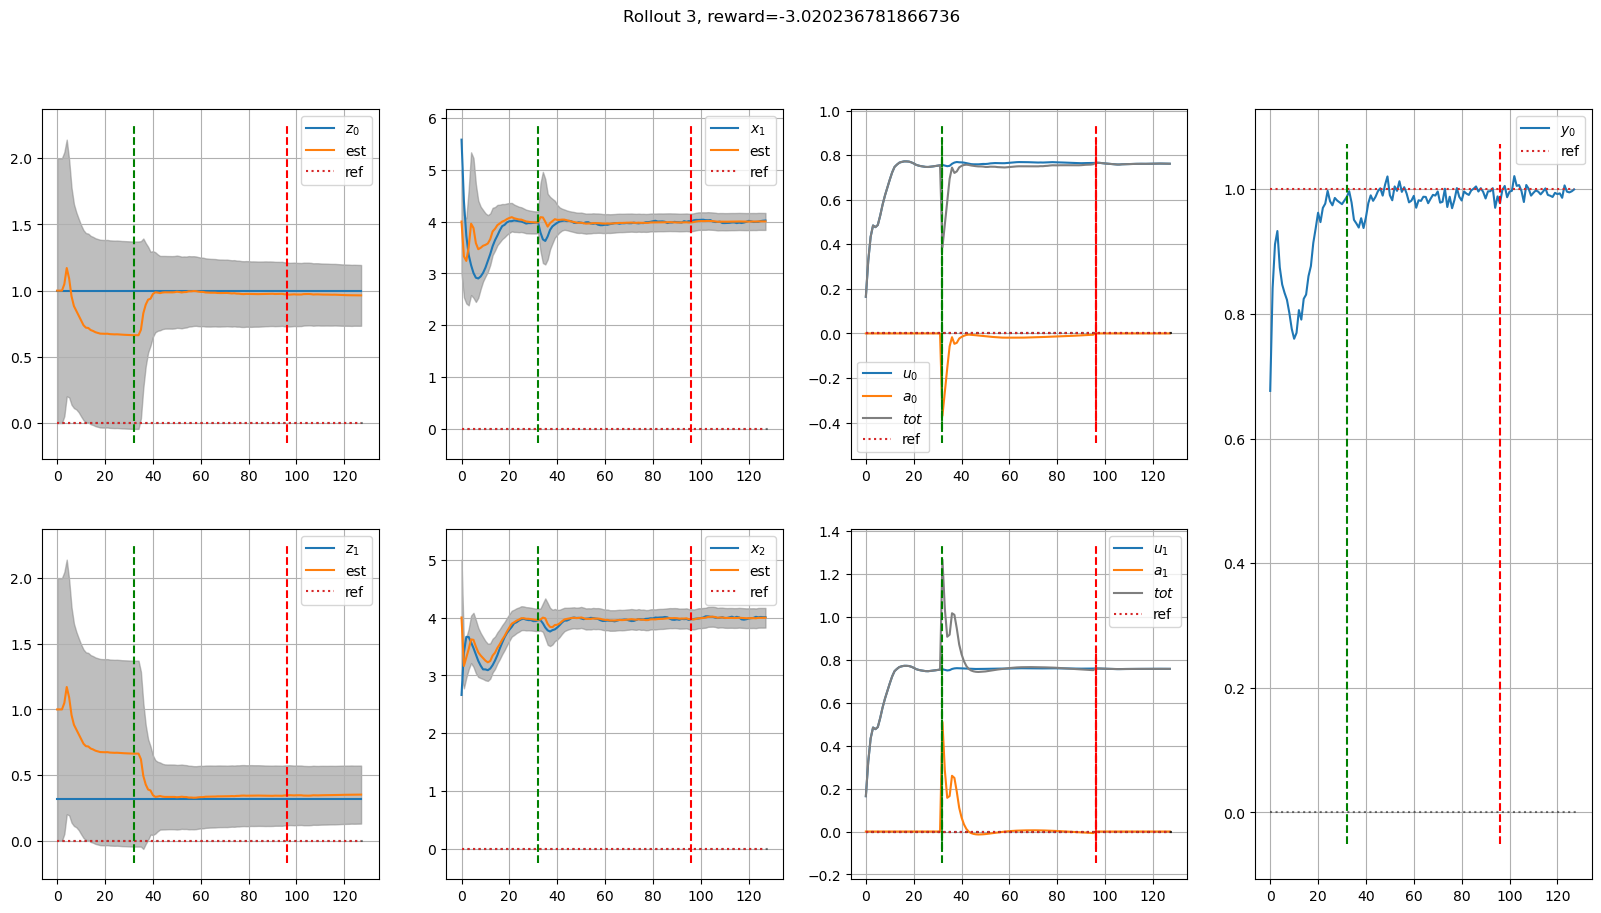

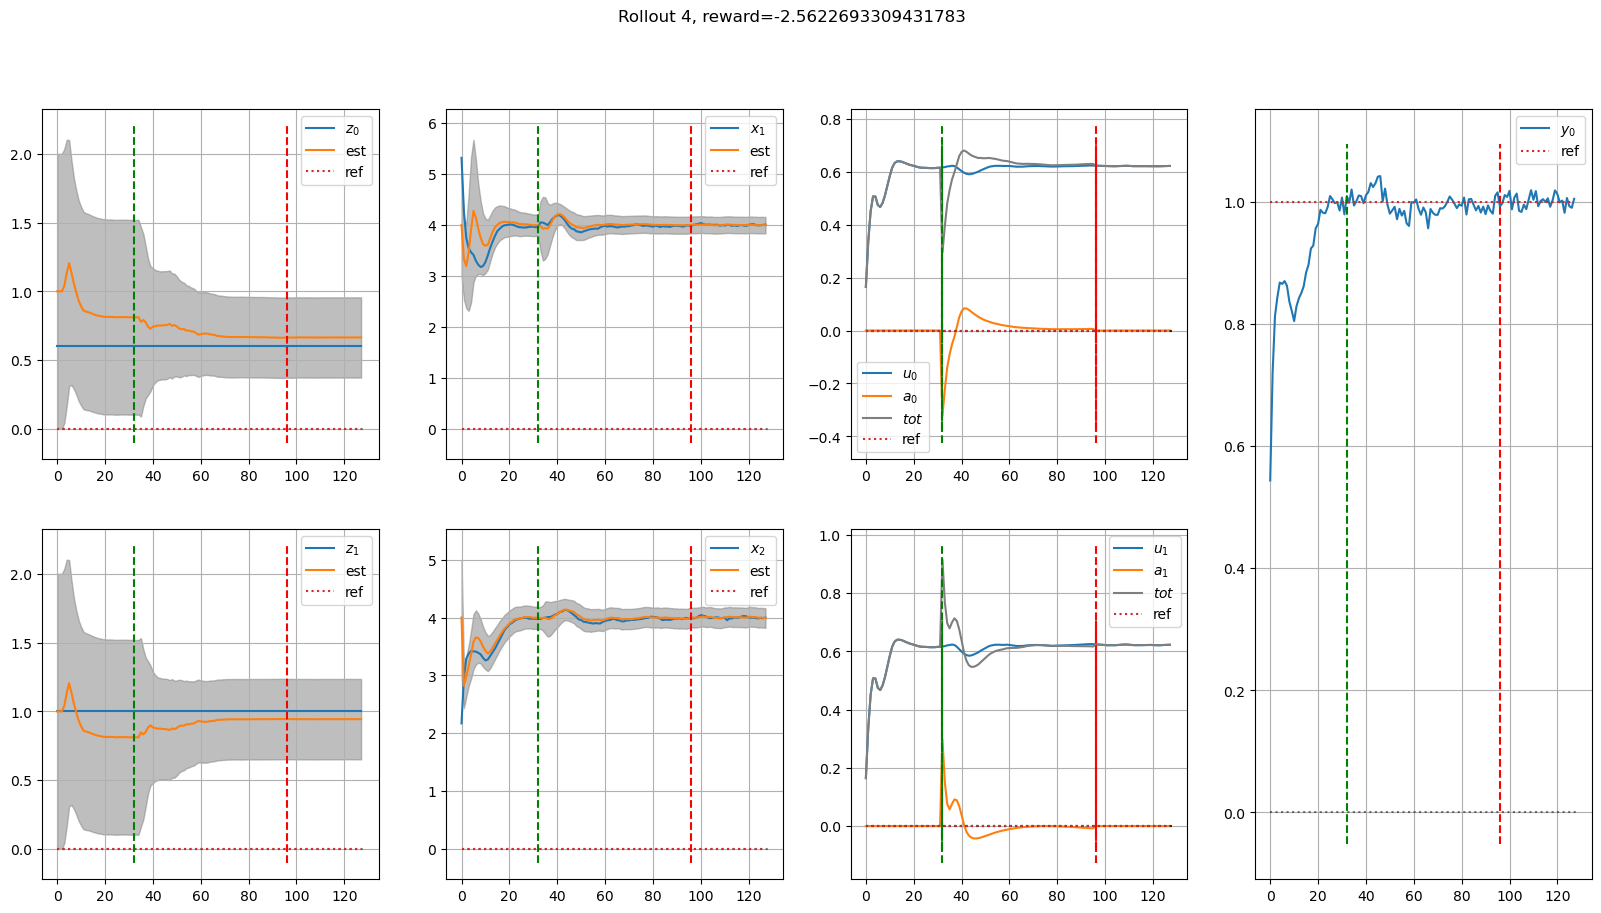

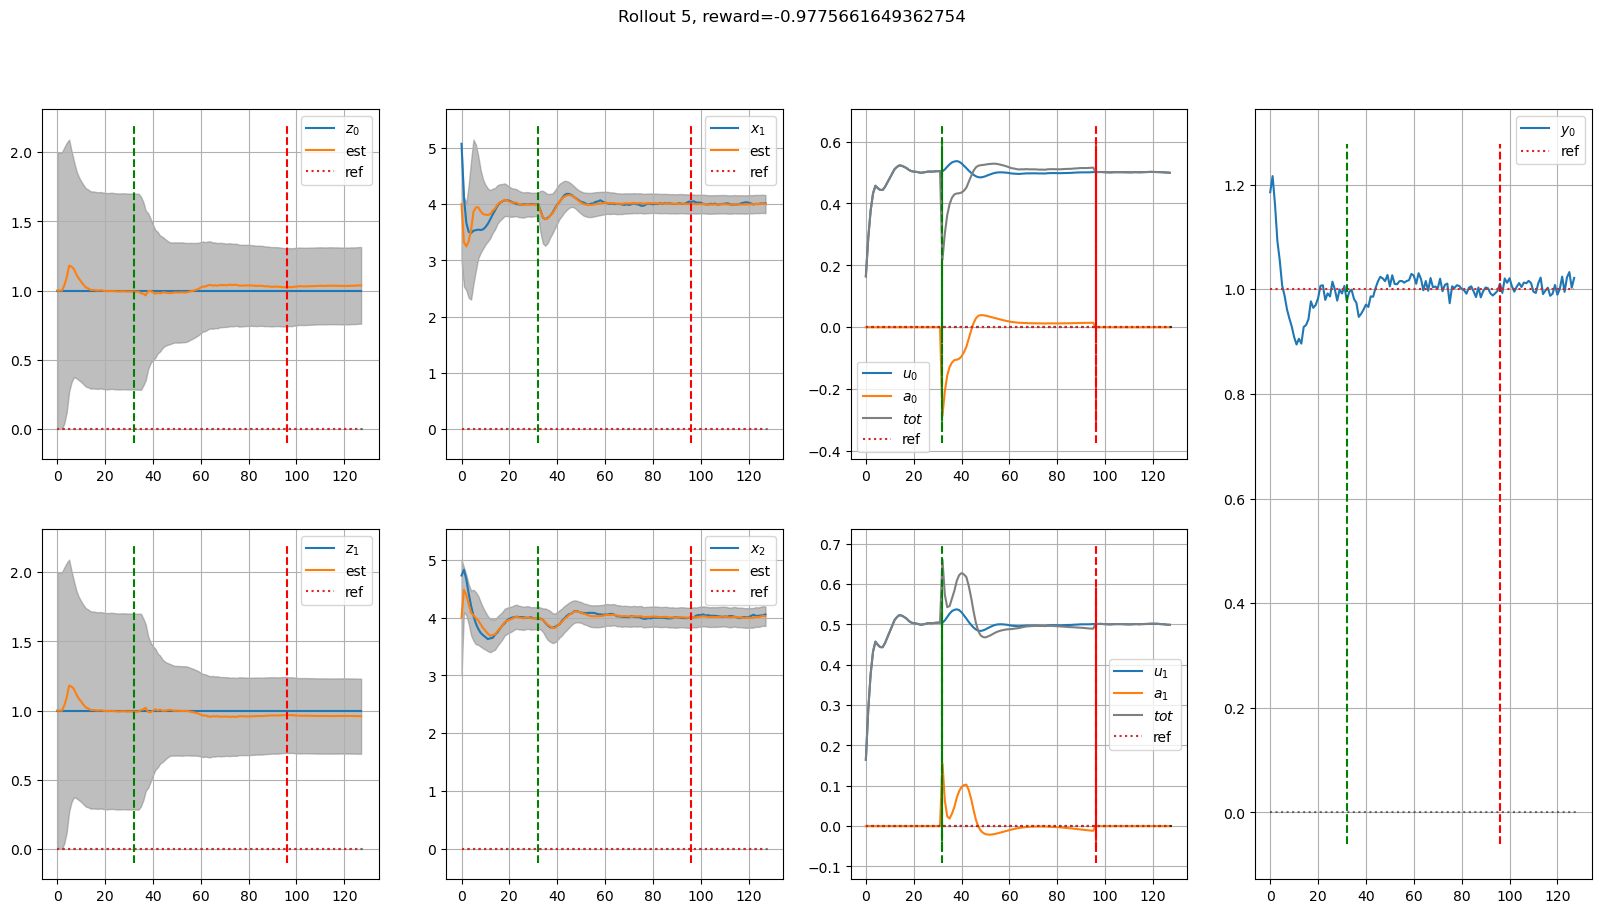

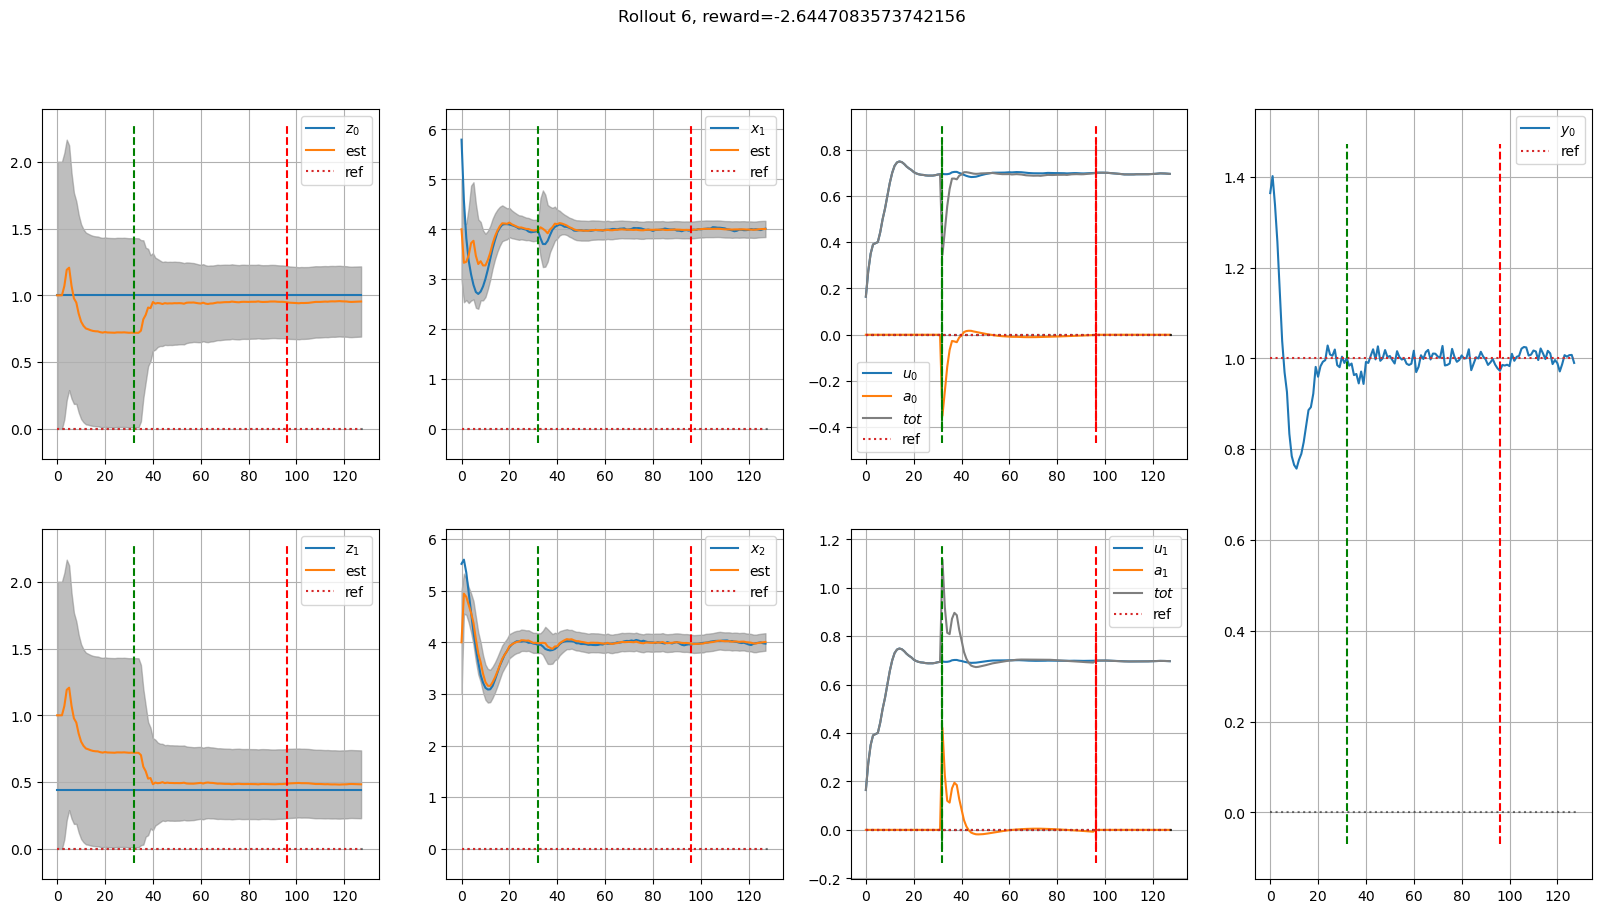

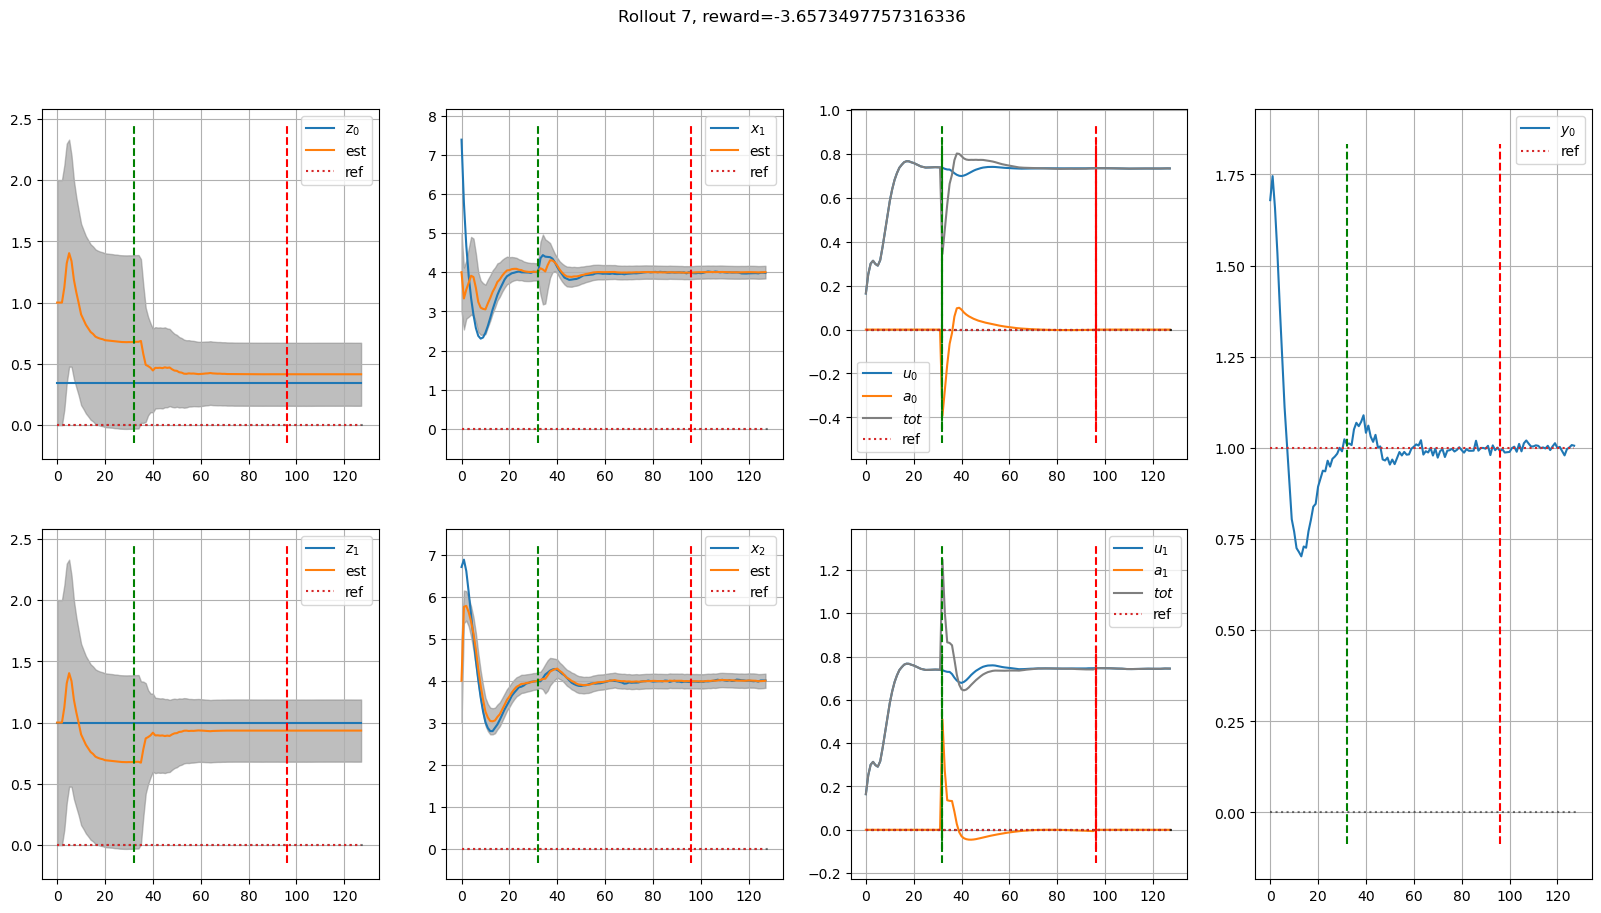

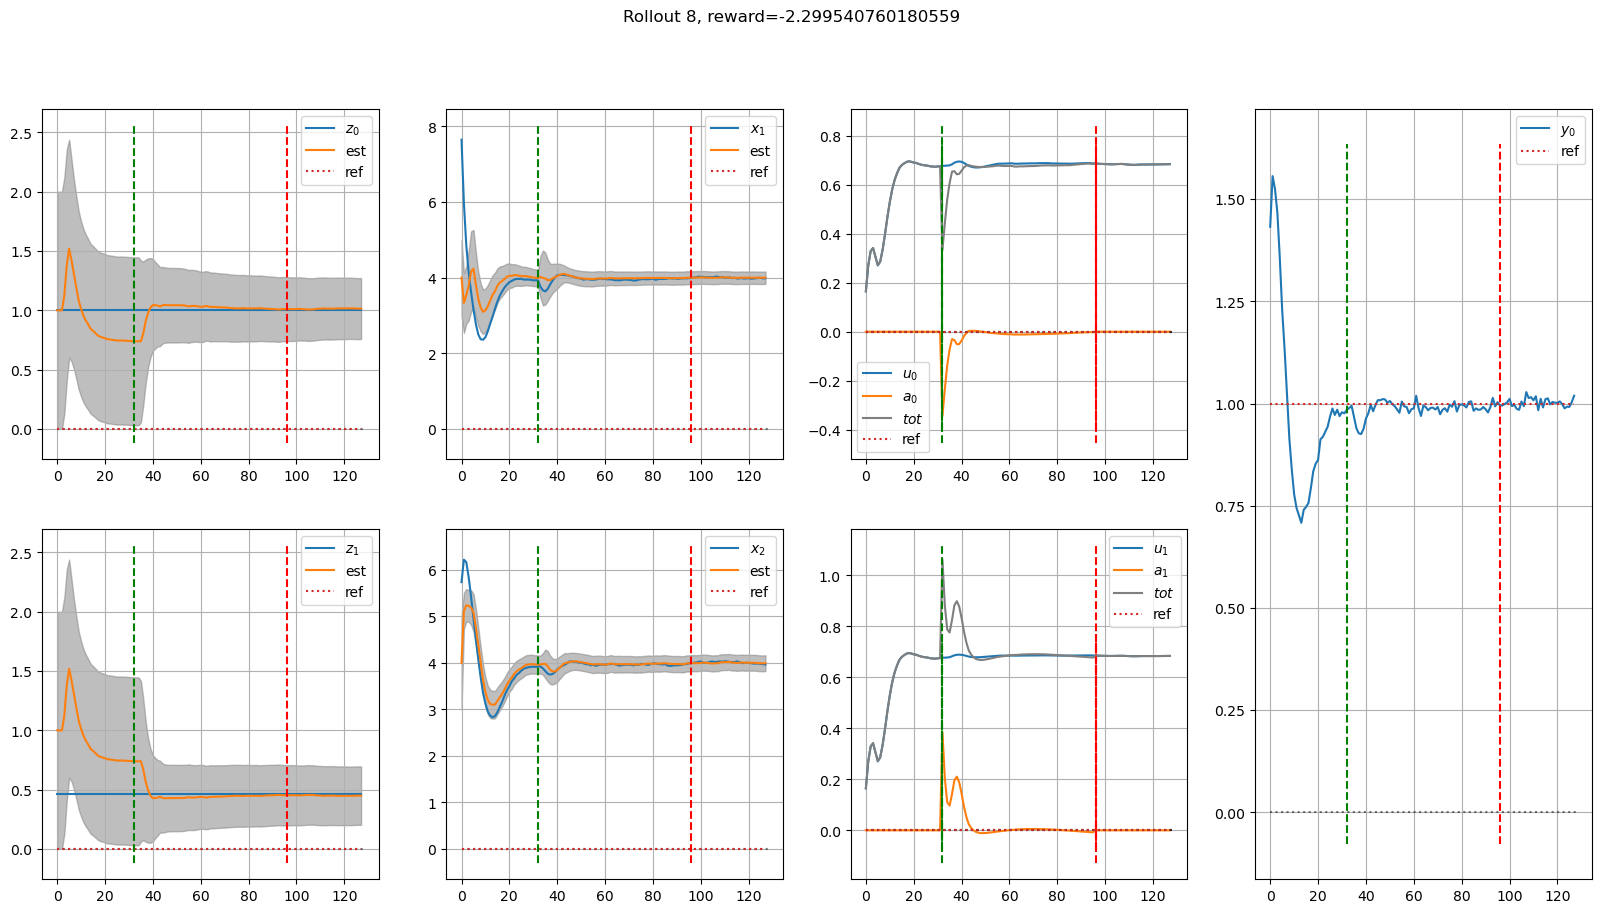

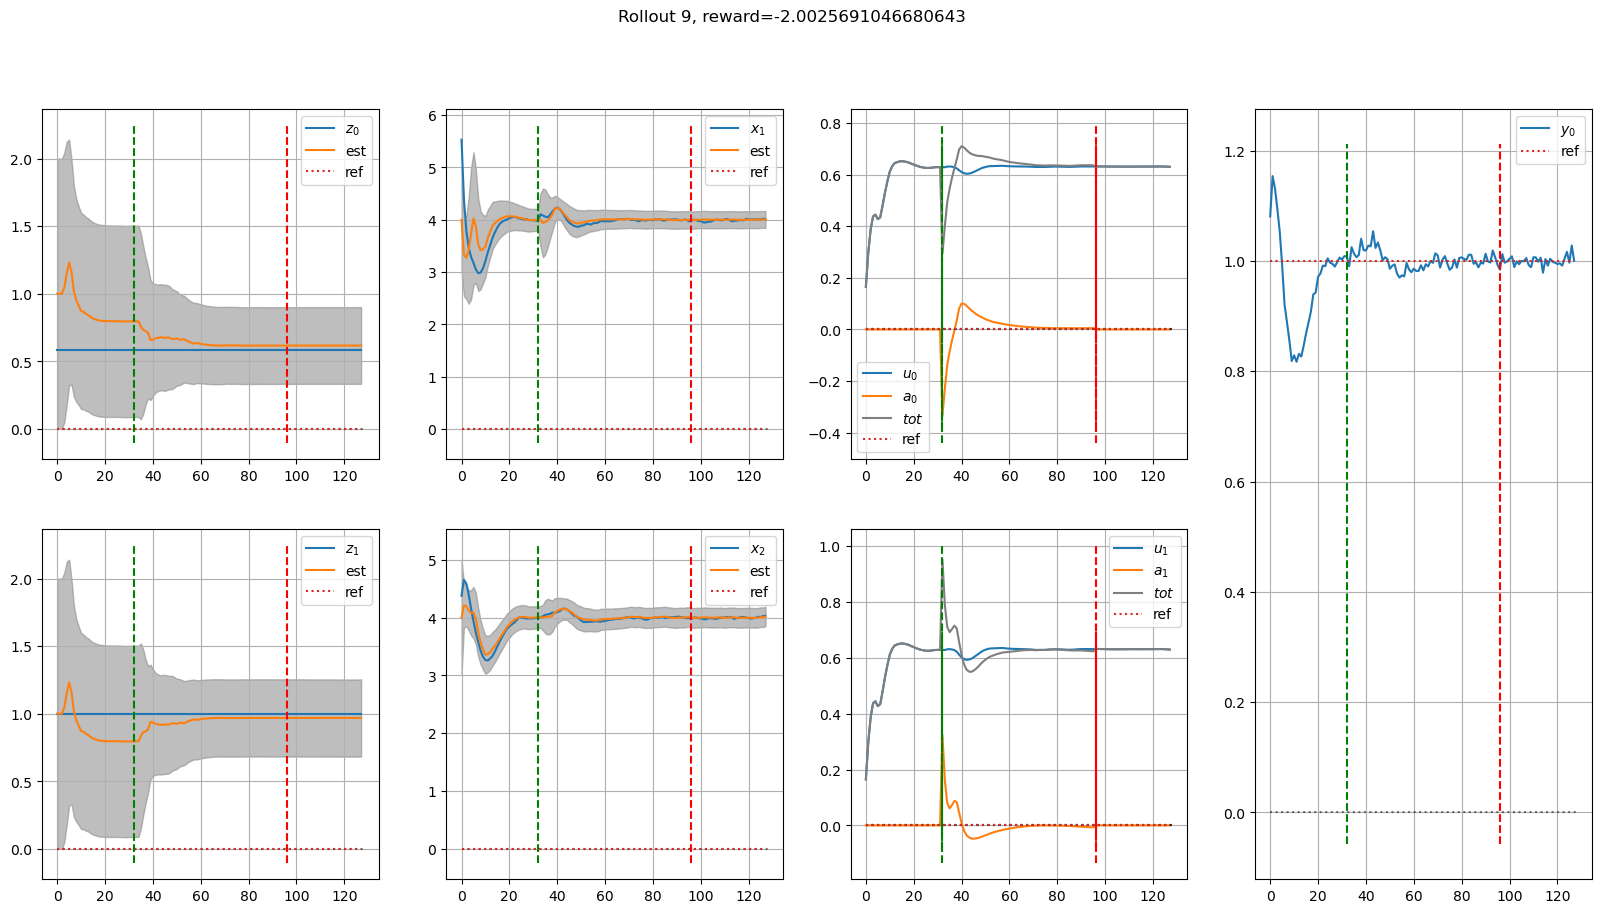

In [8]:
trainer.policy.std_diag *= 1e-20
for i in range(10):
    rollout, out = env.rollout(trainer.policy, 128)
    env.render(out, title=f"Rollout {i}, reward={rollout.r.sum()}")